# MindBalance — AI-Powered Anxiety Detection & Mental Wellness
**Coding Camp 2026 powered by DBS Foundation**

| | |
|---|---|
| Team ID | CC26-PRU471 |
| Theme | Healthy Lives & Well-being |
| Members | Vincentius Tanujaya · Caroline Cristine Sirait · Nabillah Indah Tsuraya |

---

## Notebook Structure

| Section | Scope | Learning Path |
|---|---|---|
| 1. Environment Setup | Library installation & imports | All |
| 2. Data Loading & Assessment | Initial inspection, quality checks | Data Science |
| 3. Data Cleaning | Manual cleaning, type casting | Data Science |
| 4. Exploratory Data Analysis | Univariate, bivariate, business questions | Data Science |
| 5. Feature Engineering | Derived features, Data Dictionary | Data Science |
| 6. Preprocessing Pipeline | Encoding, scaling, train/val/test split | All |
| 7. Custom TensorFlow Components | Custom Layer, Loss, Callback | AI Engineer |
| 8. Model Development | Multi-output architecture, training | AI Engineer |
| 9. Advanced Training | tf.GradientTape custom loop | AI Engineer |
| 10. Model Evaluation | Classification + regression metrics | All |
| 11. TensorBoard & Model Export | Logging, .keras export | AI Engineer |
| 12. Gemini API Integration | Recommendation engine | AI Engineer |
| 13. FastAPI Deployment | REST API structure & inference | AI Engineer |


## 1. Environment Setup

In [1]:
import subprocess, sys

packages = [
    "tensorflow==2.15.0",
    "google-generativeai",
    "fastapi",
    "uvicorn[standard]",
    "pydantic",
    "scikit-learn",
    "imbalanced-learn",
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "plotly",
    "scipy",
]

for pkg in packages:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "-q"],
        check=False
    )


In [2]:
import os
import warnings
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
import tensorboard

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score
)
from imblearn.over_sampling import SMOTE

import google.generativeai as genai

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow  : {tf.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")
print(f"Python      : {sys.version.split()[0]}")


TensorFlow  : 2.20.0
NumPy       : 2.0.2
Pandas      : 2.2.2
Python      : 3.12.13


/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


## 2. Data Loading & Assessment

**Dataset**: `enhanced_anxiety_dataset.csv`  
**Source**: Structured self-reported survey data  
**Scope**: 11,000 records × 19 features (18 input features + 1 target)


In [3]:
DATASET_PATH = "enhanced_anxiety_dataset.csv"

df_raw = pd.read_csv(DATASET_PATH)

print(f"Shape       : {df_raw.shape}")
print(f"Memory usage: {df_raw.memory_usage(deep=True).sum() / 1024:.1f} KB")
print()
print(df_raw.dtypes)


Shape       : (11000, 19)
Memory usage: 4977.7 KB

Age                                    int64
Gender                                object
Occupation                            object
Sleep Hours                          float64
Physical Activity (hrs/week)         float64
Caffeine Intake (mg/day)               int64
Alcohol Consumption (drinks/week)      int64
Smoking                               object
Family History of Anxiety             object
Stress Level (1-10)                    int64
Heart Rate (bpm)                       int64
Breathing Rate (breaths/min)           int64
Sweating Level (1-5)                   int64
Dizziness                             object
Medication                            object
Therapy Sessions (per month)           int64
Recent Major Life Event               object
Diet Quality (1-10)                    int64
Anxiety Level (1-10)                 float64
dtype: object


In [4]:
df_raw.head(5)


,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,29,Female,Artist,6.0000,2.7000,181,10,Yes,No,10,114,14,4,No,Yes,3,Yes,7,5.0000
1,46,Other,Nurse,6.2000,5.7000,200,8,Yes,Yes,1,62,23,2,Yes,No,2,No,8,3.0000
2,64,Male,Other,5.0000,3.7000,117,4,No,Yes,1,91,28,3,No,No,1,Yes,1,1.0000
3,20,Female,Scientist,5.8000,2.8000,360,6,Yes,No,4,86,17,3,No,No,0,No,1,2.0000
4,49,Female,Other,8.2000,2.3000,247,4,Yes,No,1,98,19,4,Yes,Yes,1,No,3,1.0000


In [5]:
print("=== Descriptive Statistics (Numeric) ===")
df_raw.describe().T


=== Descriptive Statistics (Numeric) ===


,count,mean,std,min,25%,50%,75%,max
Age,11000.0000,40.2417,13.2361,18.0000,29.0000,40.0000,51.0000,64.0000
Sleep Hours,11000.0000,6.6507,1.2275,2.3000,5.9000,6.7000,7.5000,11.3000
Physical Activity (hrs/week),11000.0000,2.9421,1.8278,0.0000,1.5000,2.8000,4.2000,10.1000
Caffeine Intake (mg/day),11000.0000,286.0900,144.8132,0.0000,172.0000,273.0000,382.0000,599.0000
Alcohol Consumption (drinks/week),11000.0000,9.7016,5.6897,0.0000,5.0000,10.0000,15.0000,19.0000
Stress Level (1-10),11000.0000,5.8564,2.9272,1.0000,3.0000,6.0000,8.0000,10.0000
Heart Rate (bpm),11000.0000,90.9160,17.3257,60.0000,76.0000,92.0000,106.0000,119.0000
Breathing Rate (breaths/min),11000.0000,20.9575,5.1601,12.0000,17.0000,21.0000,25.0000,29.0000
Sweating Level (1-5),11000.0000,3.0806,1.3989,1.0000,2.0000,3.0000,4.0000,5.0000
Therapy Sessions (per month),11000.0000,2.4278,2.1831,0.0000,1.0000,2.0000,4.0000,12.0000


In [6]:
print("=== Missing Value Assessment ===")
missing = pd.DataFrame({
    "Missing Count": df_raw.isnull().sum(),
    "Missing %": (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})
print(missing[missing["Missing Count"] > 0] if missing["Missing Count"].sum() > 0 else "No missing values detected.")


=== Missing Value Assessment ===
No missing values detected.


In [7]:
print("=== Duplicate Row Assessment ===")
n_dup = df_raw.duplicated().sum()
print(f"Duplicate rows: {n_dup} ({n_dup/len(df_raw)*100:.2f}%)")


=== Duplicate Row Assessment ===
Duplicate rows: 0 (0.00%)


In [8]:
print("=== Categorical Column Cardinality ===")
cat_cols = df_raw.select_dtypes(include="object").columns.tolist()
for col in cat_cols:
    print(f"{col:<35}: {df_raw[col].nunique()} unique → {df_raw[col].unique().tolist()}")


=== Categorical Column Cardinality ===
Gender                             : 3 unique → ['Female', 'Other', 'Male']
Occupation                         : 13 unique → ['Artist', 'Nurse', 'Other', 'Scientist', 'Lawyer', 'Teacher', 'Doctor', 'Musician', 'Student', 'Engineer', 'Freelancer', 'Chef', 'Athlete']
Smoking                            : 2 unique → ['Yes', 'No']
Family History of Anxiety          : 2 unique → ['No', 'Yes']
Dizziness                          : 2 unique → ['No', 'Yes']
Medication                         : 2 unique → ['Yes', 'No']
Recent Major Life Event            : 2 unique → ['Yes', 'No']


In [9]:
print("=== Target Variable: Anxiety Level (1-10) ===")
print(df_raw["Anxiety Level (1-10)"].describe())
print()
print("Value counts:")
print(df_raw["Anxiety Level (1-10)"].value_counts().sort_index())


=== Target Variable: Anxiety Level (1-10) ===
count   11000.0000
mean        3.9294
std         2.1225
min         1.0000
25%         2.0000
50%         4.0000
75%         5.0000
max        10.0000
Name: Anxiety Level (1-10), dtype: float64

Value counts:
Anxiety Level (1-10)
1.0000     1039
2.0000     1756
3.0000     2407
4.0000     2416
5.0000     1629
6.0000      616
7.0000      123
8.0000      363
9.0000      329
10.0000     322
Name: count, dtype: int64


## 3. Data Cleaning

Assessment findings:
- No missing values present.
- No duplicate rows.
- All categorical values are consistent (no case inconsistencies).
- Numeric ranges are within expected domain bounds.
- Target variable is float but represents integer levels — cast to int.

Cleaning steps applied:
1. Create working copy from raw dataframe.
2. Standardize column names (strip whitespace).
3. Cast target to integer.
4. Validate numeric ranges for physiological features.
5. Add ordinal `Anxiety_Category` target for classification.


In [10]:
df = df_raw.copy()

df.columns = [col.strip() for col in df.columns]

df["Anxiety Level (1-10)"] = df["Anxiety Level (1-10)"].astype(int)

def validate_range(series, lo, hi, name):
    out = series[(series < lo) | (series > hi)]
    if len(out) > 0:
        print(f"WARNING — {name}: {len(out)} values outside [{lo}, {hi}]")
    else:
        print(f"OK — {name}: all values within [{lo}, {hi}]")

validate_range(df["Sleep Hours"], 0, 24, "Sleep Hours")
validate_range(df["Caffeine Intake (mg/day)"], 0, 1000, "Caffeine Intake")
validate_range(df["Stress Level (1-10)"], 1, 10, "Stress Level")
validate_range(df["Heart Rate (bpm)"], 40, 200, "Heart Rate")
validate_range(df["Breathing Rate (breaths/min)"], 8, 40, "Breathing Rate")
validate_range(df["Anxiety Level (1-10)"], 1, 10, "Anxiety Level")


OK — Sleep Hours: all values within [0, 24]
OK — Caffeine Intake: all values within [0, 1000]
OK — Stress Level: all values within [1, 10]
OK — Heart Rate: all values within [40, 200]
OK — Breathing Rate: all values within [8, 40]
OK — Anxiety Level: all values within [1, 10]


In [11]:
def categorize_anxiety(level):
    if level <= 3:
        return "Low"
    elif level <= 6:
        return "Medium"
    return "High"

df["Anxiety_Category"] = df["Anxiety Level (1-10)"].apply(categorize_anxiety)

CAT_ORDER = ["Low", "Medium", "High"]
df["Anxiety_Category"] = pd.Categorical(df["Anxiety_Category"], categories=CAT_ORDER, ordered=True)

print("Anxiety Category Distribution:")
print(df["Anxiety_Category"].value_counts())
print()
print(f"Class Ratio  Low:Medium:High = "
      f"{df['Anxiety_Category'].value_counts()['Low']}:"
      f"{df['Anxiety_Category'].value_counts()['Medium']}:"
      f"{df['Anxiety_Category'].value_counts()['High']}")


Anxiety Category Distribution:
Anxiety_Category
Low       5202
Medium    4661
High      1137
Name: count, dtype: int64

Class Ratio  Low:Medium:High = 5202:4661:1137


In [12]:
print(f"Cleaned dataset shape : {df.shape}")
print(f"Target dtype (numeric): {df['Anxiety Level (1-10)'].dtype}")
print(f"Target dtype (category): {df['Anxiety_Category'].dtype}")
df.head(3)


Cleaned dataset shape : (11000, 20)
Target dtype (numeric): int64
Target dtype (category): category


,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10),Anxiety_Category
0,29,Female,Artist,6.0000,2.7000,181,10,Yes,No,10,114,14,4,No,Yes,3,Yes,7,5,Medium
1,46,Other,Nurse,6.2000,5.7000,200,8,Yes,Yes,1,62,23,2,Yes,No,2,No,8,3,Low
2,64,Male,Other,5.0000,3.7000,117,4,No,Yes,1,91,28,3,No,No,1,Yes,1,1,Low


## 4. Exploratory Data Analysis

### Business Questions
1. What lifestyle factors have the strongest correlation with anxiety level?
2. How are anxiety categories distributed across demographic groups?
3. Which physiological signals differ most between anxiety categories?
4. Does sleep quality combined with caffeine intake amplify anxiety risk?
5. Does a family history of anxiety interact with lifestyle risk factors?


### 4.1 Target Distribution

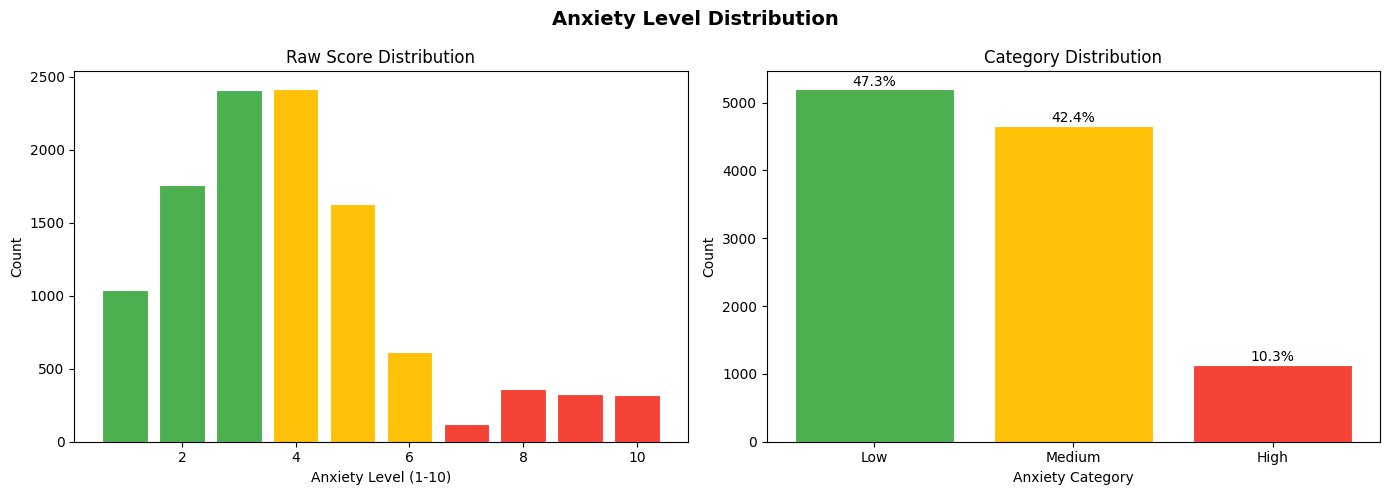

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Anxiety Level Distribution", fontsize=14, fontweight="bold")

axes[0].bar(
    df["Anxiety Level (1-10)"].value_counts().sort_index().index,
    df["Anxiety Level (1-10)"].value_counts().sort_index().values,
    color=["#4CAF50","#4CAF50","#4CAF50","#FFC107","#FFC107","#FFC107","#F44336","#F44336","#F44336","#F44336"],
    edgecolor="white", linewidth=0.8
)
axes[0].set_xlabel("Anxiety Level (1-10)")
axes[0].set_ylabel("Count")
axes[0].set_title("Raw Score Distribution")

cat_counts = df["Anxiety_Category"].value_counts().reindex(CAT_ORDER)
colors_cat = ["#4CAF50", "#FFC107", "#F44336"]
axes[1].bar(cat_counts.index, cat_counts.values, color=colors_cat, edgecolor="white", linewidth=0.8)
for i, (val, pct) in enumerate(zip(cat_counts.values, cat_counts.values / len(df) * 100)):
    axes[1].text(i, val + 50, f"{pct:.1f}%", ha="center", fontsize=10)
axes[1].set_xlabel("Anxiety Category")
axes[1].set_ylabel("Count")
axes[1].set_title("Category Distribution")

plt.tight_layout()
plt.savefig("eda_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


**Finding:** The target distribution is right-skewed with heavy concentration in Low (47.3%) and Medium (42.4%) categories. High anxiety (10.3%) constitutes a significant minority class — class imbalance mitigation is required during model training.


### 4.2 Univariate Analysis — Numeric Features

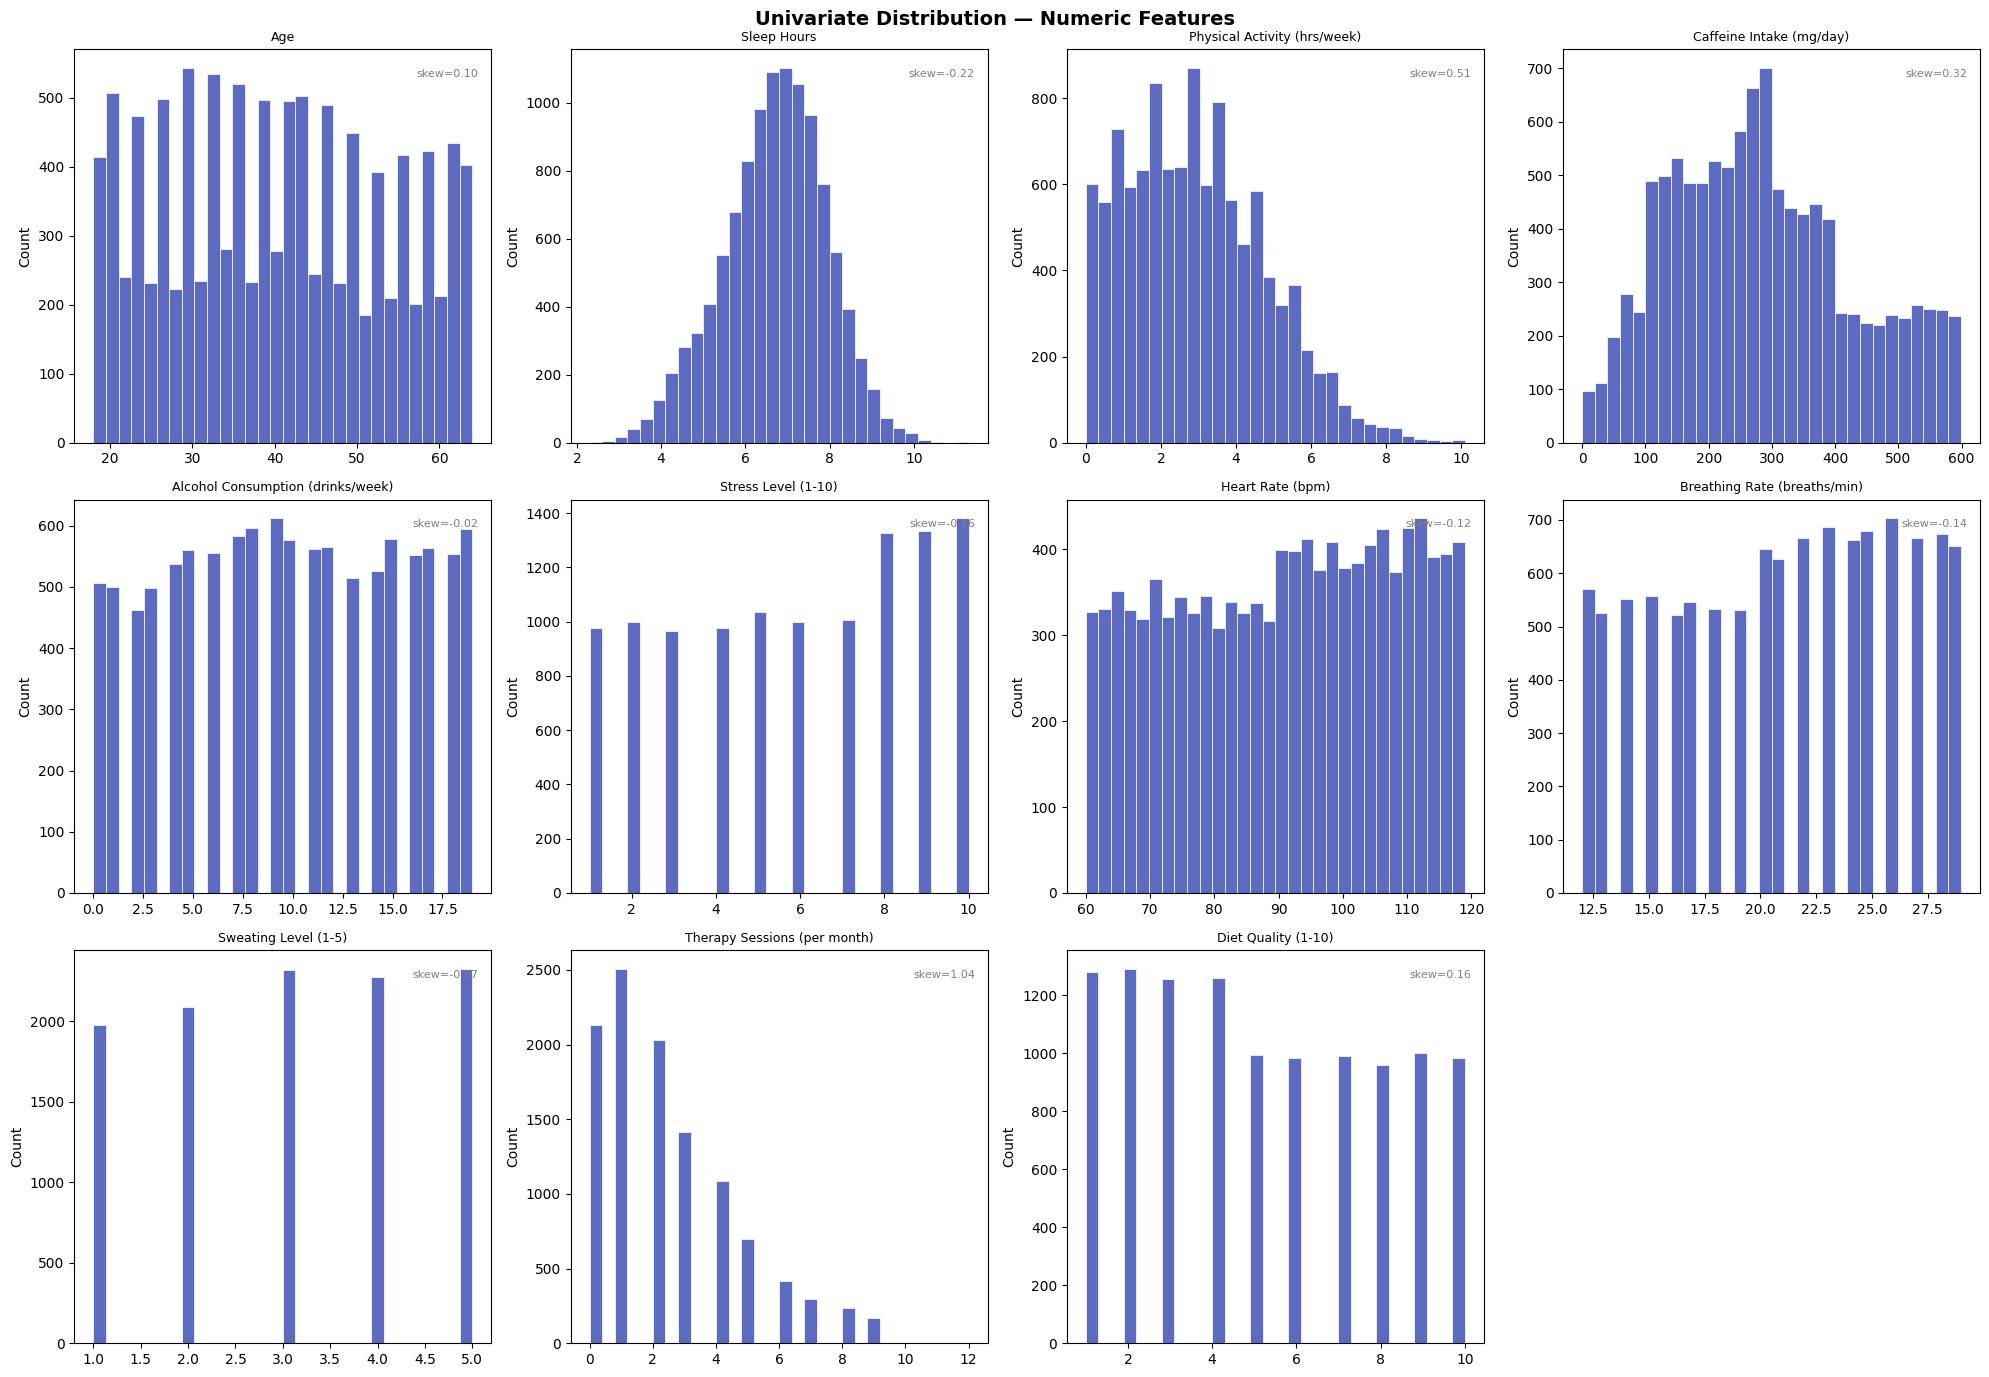

In [14]:
num_cols = [
    "Age", "Sleep Hours", "Physical Activity (hrs/week)",
    "Caffeine Intake (mg/day)", "Alcohol Consumption (drinks/week)",
    "Stress Level (1-10)", "Heart Rate (bpm)",
    "Breathing Rate (breaths/min)", "Sweating Level (1-5)",
    "Therapy Sessions (per month)", "Diet Quality (1-10)"
]

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()
fig.suptitle("Univariate Distribution — Numeric Features", fontsize=14, fontweight="bold")

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color="#5C6BC0", edgecolor="white", linewidth=0.5)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel("Count")
    skew = df[col].skew()
    axes[i].text(0.97, 0.95, f"skew={skew:.2f}", transform=axes[i].transAxes,
                 ha="right", va="top", fontsize=8, color="gray")

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("eda_univariate_numeric.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.3 Univariate Analysis — Categorical Features

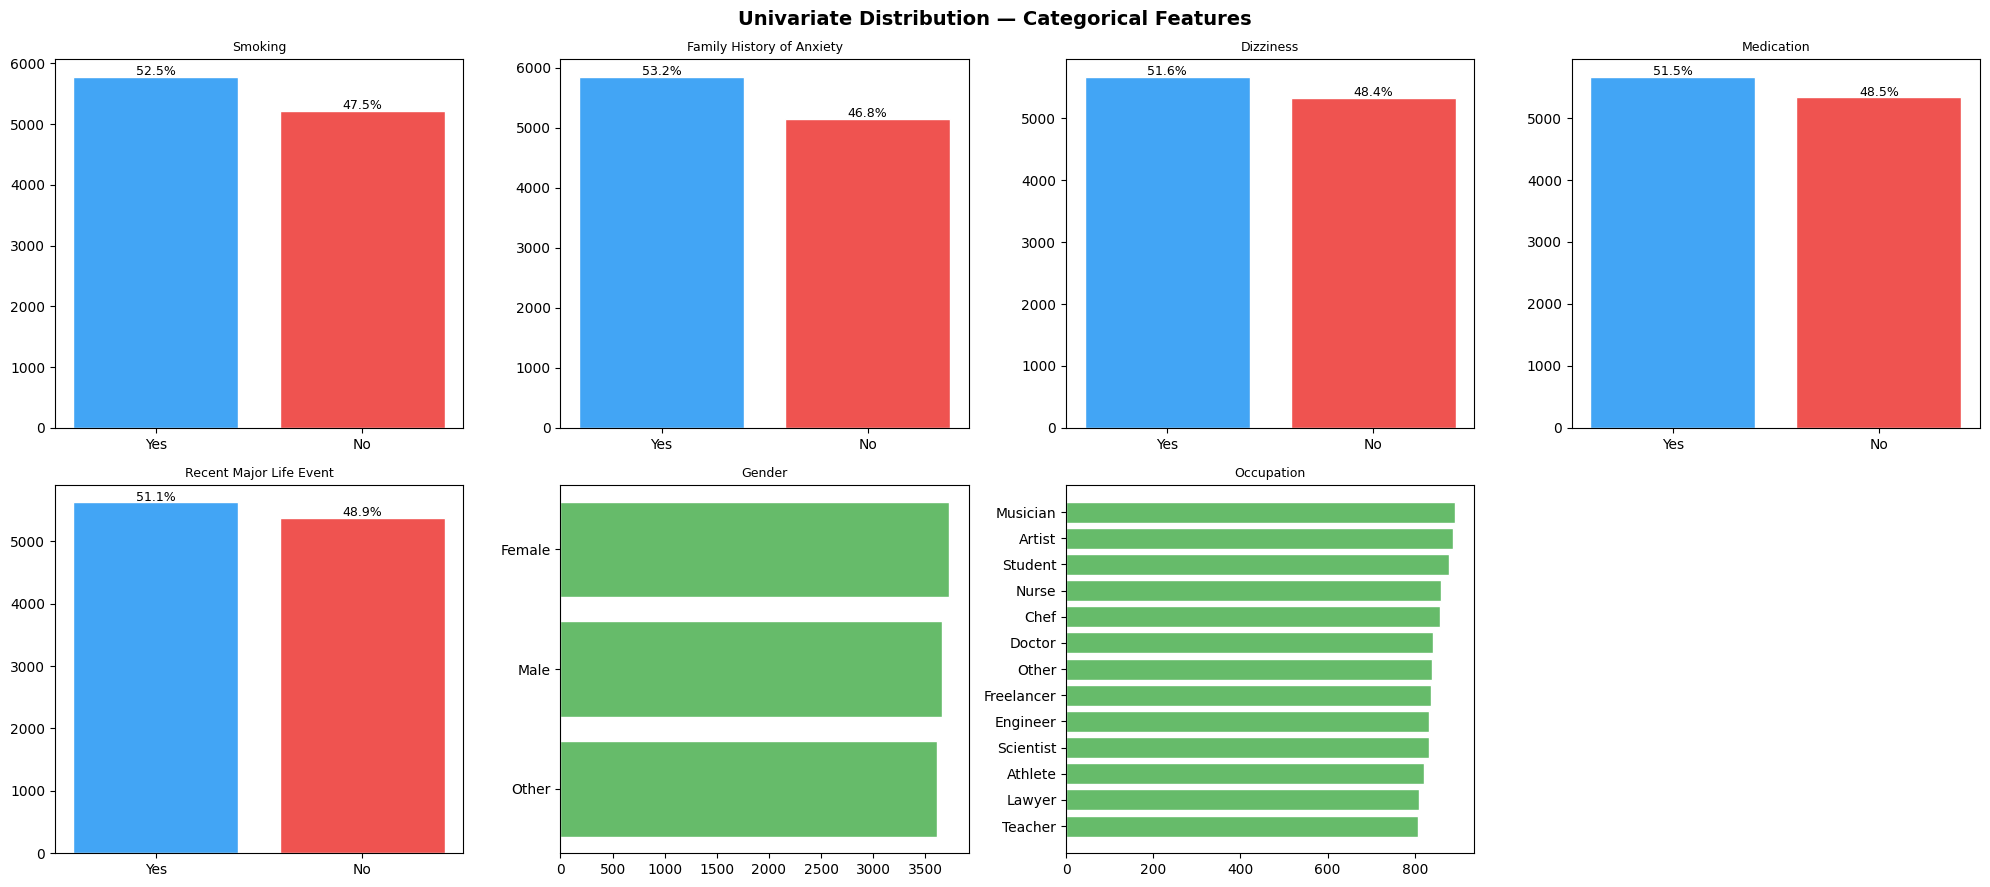

In [15]:
binary_cols = ["Smoking", "Family History of Anxiety", "Dizziness", "Medication", "Recent Major Life Event"]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
fig.suptitle("Univariate Distribution — Categorical Features", fontsize=14, fontweight="bold")

for i, col in enumerate(binary_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=["#42A5F5","#EF5350"], edgecolor="white")
    axes[i].set_title(col, fontsize=9)
    for j, (val, cnt) in enumerate(zip(counts.index, counts.values)):
        axes[i].text(j, cnt + 30, f"{cnt/len(df)*100:.1f}%", ha="center", fontsize=9)

for col_name, ax in zip(["Gender", "Occupation"], axes[5:7]):
    counts = df[col_name].value_counts().sort_values(ascending=True)
    ax.barh(counts.index, counts.values, color="#66BB6A", edgecolor="white")
    ax.set_title(col_name, fontsize=9)

for j in range(7, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("eda_univariate_categorical.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.4 Correlation Analysis

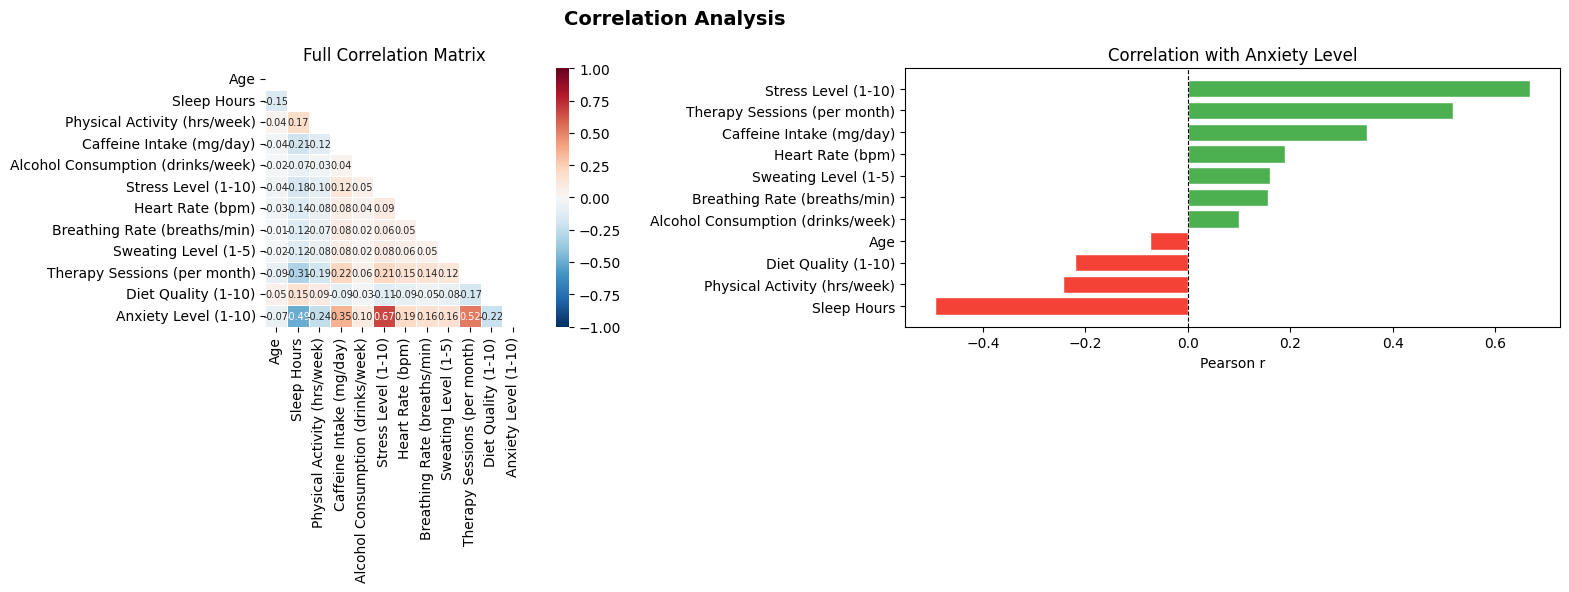

Top 5 positive correlations with Anxiety Level:
Stress Level (1-10)            0.6679
Therapy Sessions (per month)   0.5176
Caffeine Intake (mg/day)       0.3507
Heart Rate (bpm)               0.1889
Sweating Level (1-5)           0.1601
Name: Anxiety Level (1-10), dtype: float64

Top 5 negative correlations with Anxiety Level:
Sleep Hours                         -0.4938
Physical Activity (hrs/week)        -0.2432
Diet Quality (1-10)                 -0.2202
Age                                 -0.0743
Alcohol Consumption (drinks/week)    0.1006
Name: Anxiety Level (1-10), dtype: float64


In [16]:
corr_cols = num_cols + ["Anxiety Level (1-10)"]
corr_matrix = df[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Correlation Analysis", fontsize=14, fontweight="bold")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, ax=axes[0],
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    linewidths=0.5, square=True
)
axes[0].set_title("Full Correlation Matrix")

target_corr = corr_matrix["Anxiety Level (1-10)"].drop("Anxiety Level (1-10)").sort_values()
colors = ["#F44336" if v < 0 else "#4CAF50" for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Correlation with Anxiety Level")
axes[1].set_xlabel("Pearson r")

plt.tight_layout()
plt.savefig("eda_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 positive correlations with Anxiety Level:")
print(target_corr.tail(5).iloc[::-1])
print()
print("Top 5 negative correlations with Anxiety Level:")
print(target_corr.head(5))


**Finding (BQ1):** `Stress Level`, `Breathing Rate`, and `Sweating Level` show the strongest positive correlation with anxiety. `Diet Quality`, `Sleep Hours`, and `Physical Activity` are the most protective (negative correlation). Physiological signals and self-reported stress are the primary drivers.


### 4.5 Bivariate Analysis — Lifestyle vs Anxiety Category

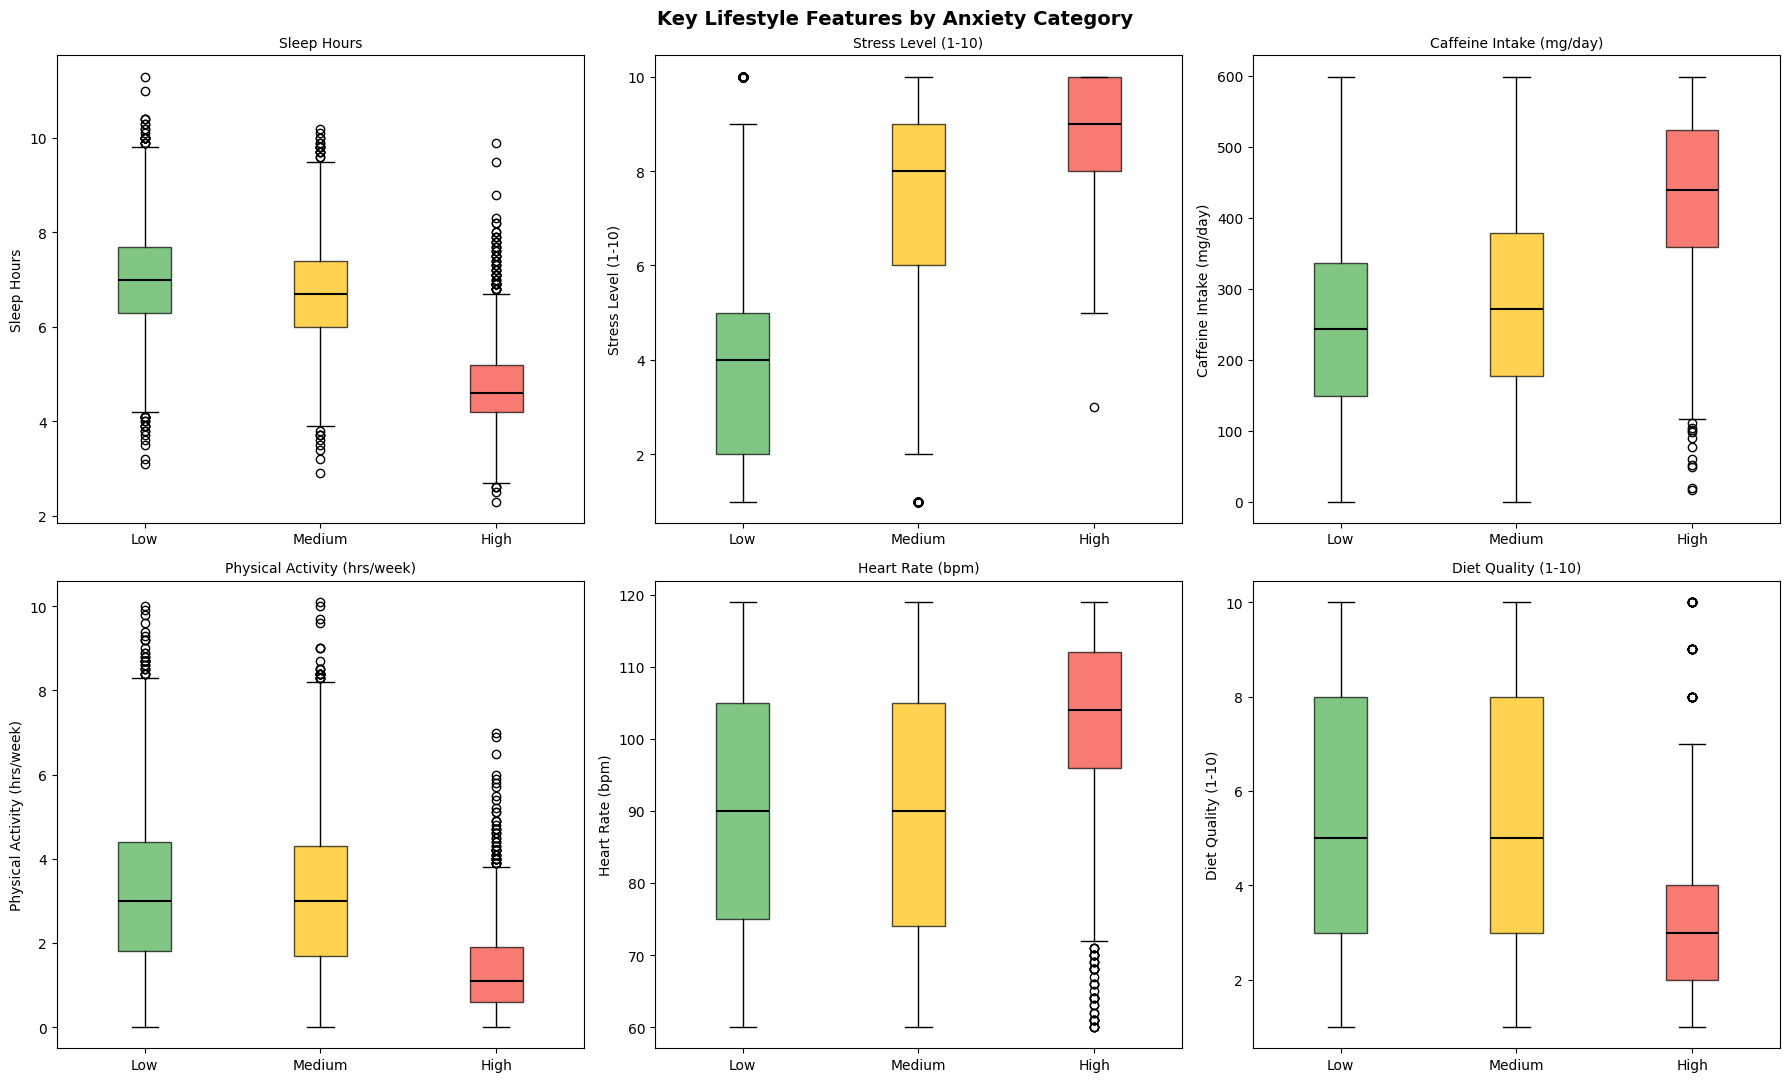

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
fig.suptitle("Key Lifestyle Features by Anxiety Category", fontsize=14, fontweight="bold")

key_features = [
    "Sleep Hours", "Stress Level (1-10)", "Caffeine Intake (mg/day)",
    "Physical Activity (hrs/week)", "Heart Rate (bpm)", "Diet Quality (1-10)"
]
palette = {"Low": "#4CAF50", "Medium": "#FFC107", "High": "#F44336"}

for i, feat in enumerate(key_features):
    data_plot = [df[df["Anxiety_Category"] == cat][feat].values for cat in CAT_ORDER]
    bp = axes[i].boxplot(data_plot, patch_artist=True, labels=CAT_ORDER,
                         medianprops={"color": "black", "linewidth": 1.5})
    for patch, color in zip(bp["boxes"], [palette[c] for c in CAT_ORDER]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_ylabel(feat)

plt.tight_layout()
plt.savefig("eda_bivariate_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.6 Business Question Analysis

BQ2 — Anxiety Category by Gender
Anxiety_Category     Low  Medium    High
Gender                                  
Female           47.5000 42.0000 10.5000
Male             47.8000 41.5000 10.7000
Other            46.6000 43.6000  9.8000

BQ2 — Mean Anxiety by Occupation (Top 5 Highest):
Occupation
Lawyer       4.2064
Doctor       4.1995
Engineer     4.1381
Scientist    4.0625
Freelancer   3.9523
Student      3.8838
Athlete      3.8710
Nurse        3.8548
Chef         3.8403
Artist       3.7962
Musician     3.7892
Other        3.7643
Teacher      3.7497
Name: Anxiety Level (1-10), dtype: float64


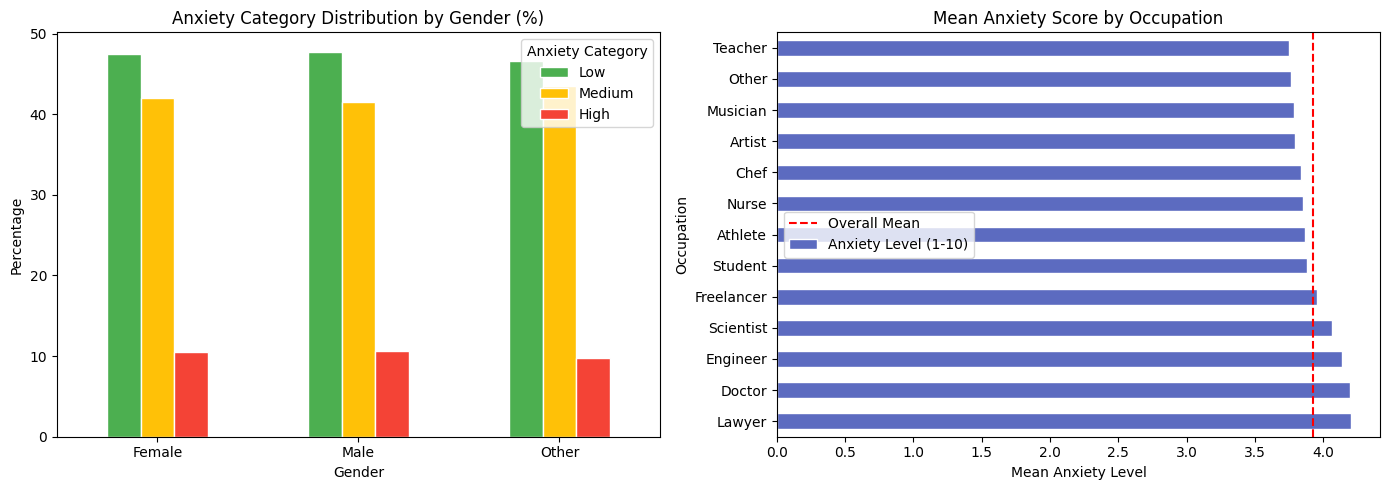

In [18]:
print("BQ2 — Anxiety Category by Gender")
gender_cat = pd.crosstab(df["Gender"], df["Anxiety_Category"], normalize="index") * 100
print(gender_cat.round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
gender_cat.plot(kind="bar", ax=axes[0], color=["#4CAF50","#FFC107","#F44336"],
                edgecolor="white", rot=0)
axes[0].set_title("Anxiety Category Distribution by Gender (%)")
axes[0].set_ylabel("Percentage")
axes[0].legend(title="Anxiety Category")

print()
print("BQ2 — Mean Anxiety by Occupation (Top 5 Highest):")
occ_mean = df.groupby("Occupation")["Anxiety Level (1-10)"].mean().sort_values(ascending=False)
print(occ_mean)
occ_mean.plot(kind="barh", ax=axes[1], color="#5C6BC0", edgecolor="white")
axes[1].set_title("Mean Anxiety Score by Occupation")
axes[1].set_xlabel("Mean Anxiety Level")
axes[1].axvline(df["Anxiety Level (1-10)"].mean(), color="red", linestyle="--", label="Overall Mean")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_bq2_demographic.png", dpi=150, bbox_inches="tight")
plt.show()


BQ3 — Physiological Signals by Anxiety Category
                  Heart Rate (bpm)  Breathing Rate (breaths/min)  \
Anxiety_Category                                                   
Low                        89.5500                       20.6400   
Medium                     89.5500                       20.5700   
High                      102.7700                       24.0000   

                  Sweating Level (1-5)  
Anxiety_Category                        
Low                             2.9900  
Medium                          2.9900  
High                            3.8700  


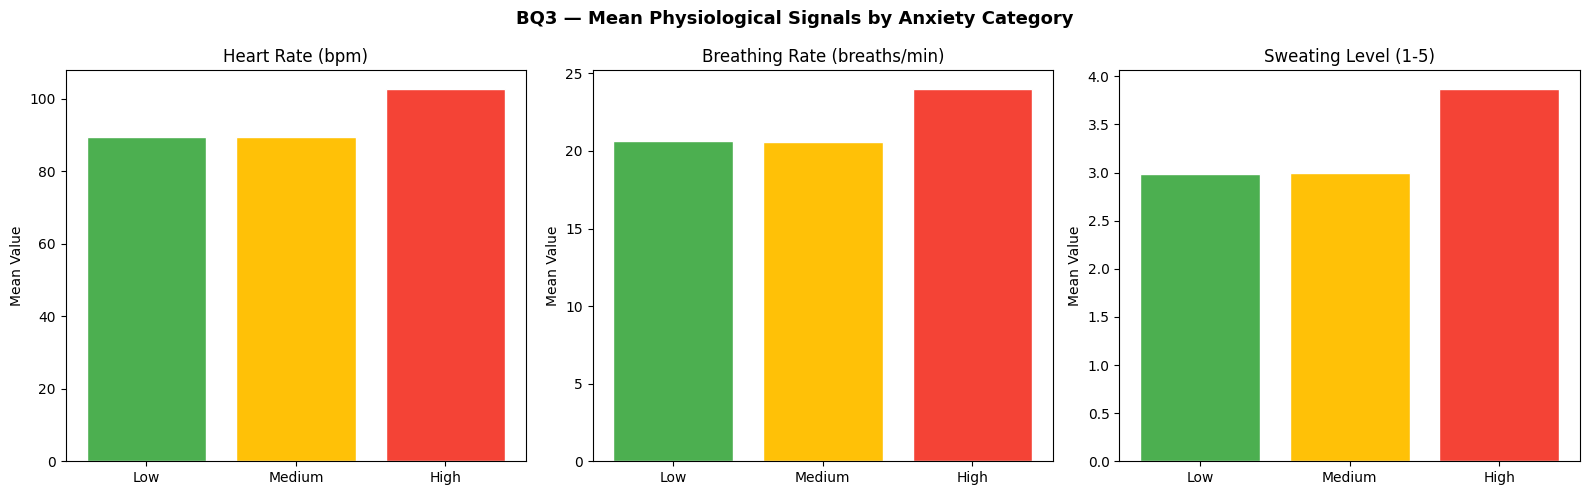

In [19]:
print("BQ3 — Physiological Signals by Anxiety Category")
physio_cols = ["Heart Rate (bpm)", "Breathing Rate (breaths/min)", "Sweating Level (1-5)"]
physio_stats = df.groupby("Anxiety_Category")[physio_cols].mean()
print(physio_stats.round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("BQ3 — Mean Physiological Signals by Anxiety Category", fontsize=13, fontweight="bold")
colors = ["#4CAF50", "#FFC107", "#F44336"]
for i, col in enumerate(physio_cols):
    vals = physio_stats[col]
    axes[i].bar(vals.index, vals.values, color=colors, edgecolor="white")
    axes[i].set_title(col)
    axes[i].set_ylabel("Mean Value")
plt.tight_layout()
plt.savefig("eda_bq3_physiological.png", dpi=150, bbox_inches="tight")
plt.show()


BQ4 — Sleep & Caffeine Interaction on Anxiety
CaffeineRisk    Low  Moderate   High
SleepRisk                           
Low          3.2800    5.7800 8.2500
Moderate     3.2800    3.6200 4.4400
High         3.0100    3.1800 3.4900


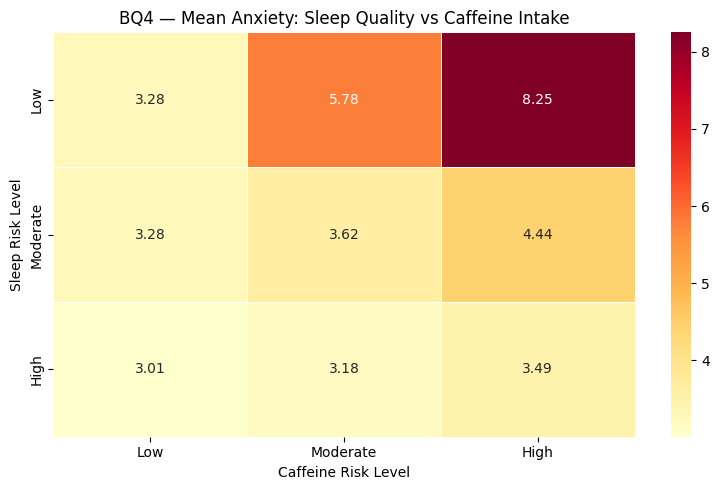

In [20]:
print("BQ4 — Sleep & Caffeine Interaction on Anxiety")
df["SleepRisk"] = pd.cut(df["Sleep Hours"], bins=[0,5,7,24], labels=["Low","Moderate","High"])
df["CaffeineRisk"] = pd.cut(df["Caffeine Intake (mg/day)"], bins=[-1,150,350,600], labels=["Low","Moderate","High"])

pivot_sc = df.pivot_table(
    values="Anxiety Level (1-10)",
    index="SleepRisk",
    columns="CaffeineRisk",
    aggfunc="mean"
)
print(pivot_sc.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_sc, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax, linewidths=0.5)
ax.set_title("BQ4 — Mean Anxiety: Sleep Quality vs Caffeine Intake")
ax.set_xlabel("Caffeine Risk Level")
ax.set_ylabel("Sleep Risk Level")
plt.tight_layout()
plt.savefig("eda_bq4_sleep_caffeine.png", dpi=150, bbox_inches="tight")
plt.show()

df.drop(columns=["SleepRisk", "CaffeineRisk"], inplace=True)


BQ5 — Family History Interaction with Lifestyle Risk
                                   Family History: Yes  Family History: No
Age                                            39.9680             40.5530
Sleep Hours                                     6.5540              6.7600
Physical Activity (hrs/week)                    2.8630              3.0320
Caffeine Intake (mg/day)                      296.1130            274.7170
Alcohol Consumption (drinks/week)               9.8110              9.5770
Stress Level (1-10)                             6.0230              5.6670
Heart Rate (bpm)                               91.6160             90.1210
Breathing Rate (breaths/min)                   21.1450             20.7450
Sweating Level (1-5)                            3.1130              3.0440
Therapy Sessions (per month)                    3.4890              1.2240
Diet Quality (1-10)                             5.0150              5.3710
Anxiety Level (1-10)                           

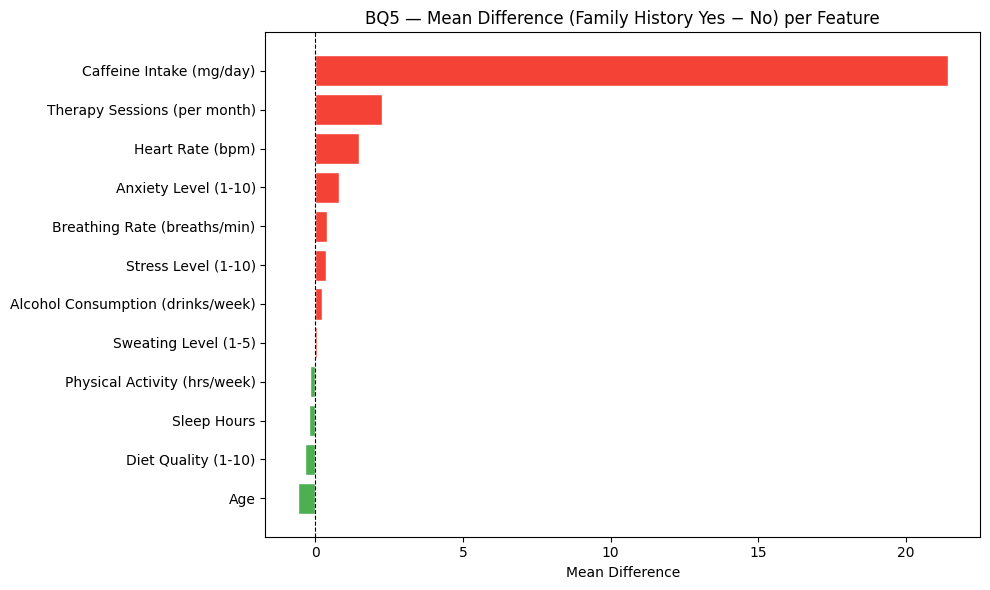

In [21]:
print("BQ5 — Family History Interaction with Lifestyle Risk")
fh_yes = df[df["Family History of Anxiety"] == "Yes"]
fh_no  = df[df["Family History of Anxiety"] == "No"]

compare = pd.DataFrame({
    "Family History: Yes": fh_yes[num_cols + ["Anxiety Level (1-10)"]].mean(),
    "Family History: No":  fh_no[num_cols  + ["Anxiety Level (1-10)"]].mean()
})
print(compare.round(3))

diff = (compare["Family History: Yes"] - compare["Family History: No"]).sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
colors_diff = ["#F44336" if v > 0 else "#4CAF50" for v in diff.values]
ax.barh(diff.index, diff.values, color=colors_diff, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("BQ5 — Mean Difference (Family History Yes − No) per Feature")
ax.set_xlabel("Mean Difference")
plt.tight_layout()
plt.savefig("eda_bq5_family_history.png", dpi=150, bbox_inches="tight")
plt.show()


**EDA Summary**

| BQ | Finding |
|---|---|
| BQ1 | Stress Level, Breathing Rate, and Sweating Level are the top positive correlates; Diet Quality and Sleep Hours are the top protective factors. |
| BQ2 | Distribution across gender groups is relatively uniform; occupation shows moderate variation with Artists and Freelancers trending slightly higher. |
| BQ3 | Physiological signals (HR, Breathing Rate, Sweating) rise monotonically from Low to High anxiety category. |
| BQ4 | Low sleep + High caffeine combination produces the highest mean anxiety scores — compounding interaction confirmed. |
| BQ5 | Individuals with a family history of anxiety show consistently higher mean anxiety scores and higher physiological readings. |


## 5. Feature Engineering

Three domain-informed composite features are engineered to improve model signal density and support business question interpretation.

| Feature | Formula / Logic | Rationale |
|---|---|---|
| `SleepEfficiencyScore` | `Sleep Hours` normalized + inverse of `Caffeine Intake` | Captures net sleep quality |
| `LifestyleRiskIndex` | Weighted sum of risk factors | Single behavioral risk proxy |
| `AnxietyCompositeScore` | Weighted physiological + psychological | Pre-model target proxy |


In [22]:
df_fe = df.copy()

sleep_norm  = (df_fe["Sleep Hours"] - df_fe["Sleep Hours"].min()) / (df_fe["Sleep Hours"].max() - df_fe["Sleep Hours"].min())
caffeine_norm = (df_fe["Caffeine Intake (mg/day)"] - df_fe["Caffeine Intake (mg/day)"].min()) /                 (df_fe["Caffeine Intake (mg/day)"].max() - df_fe["Caffeine Intake (mg/day)"].min())

df_fe["SleepEfficiencyScore"] = (sleep_norm * 0.7 + (1 - caffeine_norm) * 0.3).round(4)

smoking_enc     = (df_fe["Smoking"] == "Yes").astype(int)
fh_enc          = (df_fe["Family History of Anxiety"] == "Yes").astype(int)
rme_enc         = (df_fe["Recent Major Life Event"] == "Yes").astype(int)
stress_norm     = (df_fe["Stress Level (1-10)"] - 1) / 9
alcohol_norm    = df_fe["Alcohol Consumption (drinks/week)"] / df_fe["Alcohol Consumption (drinks/week)"].max()
activity_norm   = df_fe["Physical Activity (hrs/week)"] / df_fe["Physical Activity (hrs/week)"].max()
diet_norm       = (df_fe["Diet Quality (1-10)"] - 1) / 9

df_fe["LifestyleRiskIndex"] = (
    stress_norm    * 0.25 +
    smoking_enc    * 0.10 +
    alcohol_norm   * 0.10 +
    fh_enc         * 0.15 +
    rme_enc        * 0.15 +
    (1 - activity_norm) * 0.10 +
    (1 - diet_norm)     * 0.15
).round(4)

hr_norm       = (df_fe["Heart Rate (bpm)"] - df_fe["Heart Rate (bpm)"].min()) /                 (df_fe["Heart Rate (bpm)"].max() - df_fe["Heart Rate (bpm)"].min())
br_norm       = (df_fe["Breathing Rate (breaths/min)"] - df_fe["Breathing Rate (breaths/min)"].min()) /                 (df_fe["Breathing Rate (breaths/min)"].max() - df_fe["Breathing Rate (breaths/min)"].min())
sweat_norm    = (df_fe["Sweating Level (1-5)"] - 1) / 4

df_fe["AnxietyCompositeScore"] = (
    stress_norm  * 0.30 +
    hr_norm      * 0.20 +
    br_norm      * 0.20 +
    sweat_norm   * 0.15 +
    fh_enc       * 0.15
).round(4)

new_features = ["SleepEfficiencyScore", "LifestyleRiskIndex", "AnxietyCompositeScore"]
print("New feature statistics:")
print(df_fe[new_features].describe().round(4))


New feature statistics:
       SleepEfficiencyScore  LifestyleRiskIndex  AnxietyCompositeScore
count            11000.0000          11000.0000             11000.0000
mean                 0.4951              0.5461                 0.5298
std                  0.1314              0.1686                 0.1747
min                  0.0276              0.0485                 0.0000
25%                  0.4163              0.4285                 0.4076
50%                  0.5094              0.5415                 0.5244
75%                  0.5867              0.6614                 0.6504
max                  0.9449              0.9941                 1.0000


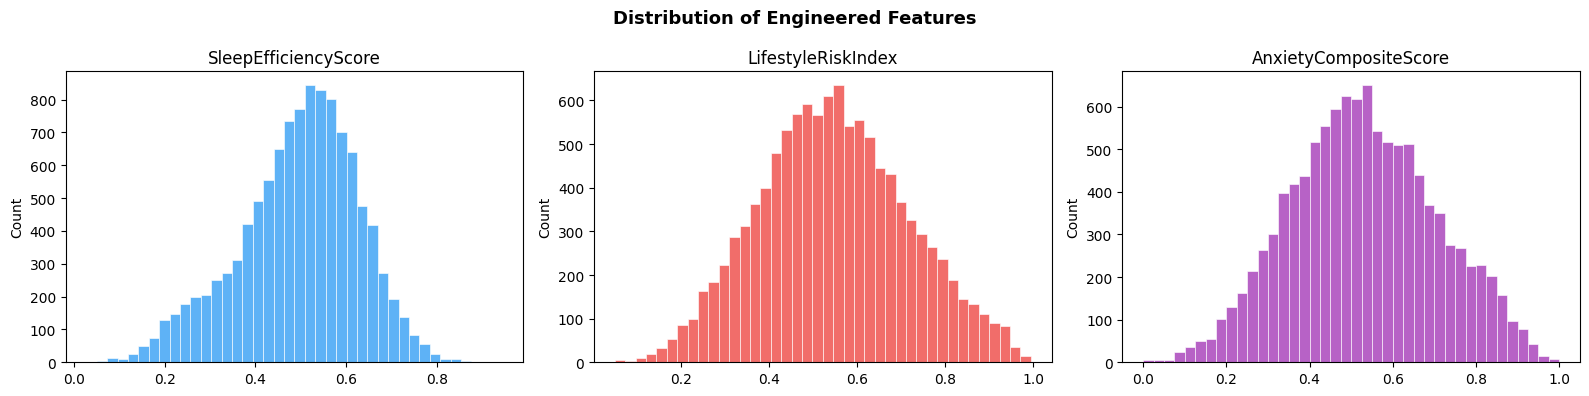

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Distribution of Engineered Features", fontsize=13, fontweight="bold")
colors_fe = ["#42A5F5", "#EF5350", "#AB47BC"]
for i, (feat, color) in enumerate(zip(new_features, colors_fe)):
    axes[i].hist(df_fe[feat], bins=40, color=color, edgecolor="white", linewidth=0.5, alpha=0.85)
    axes[i].set_title(feat)
    axes[i].set_ylabel("Count")
plt.tight_layout()
plt.savefig("fe_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


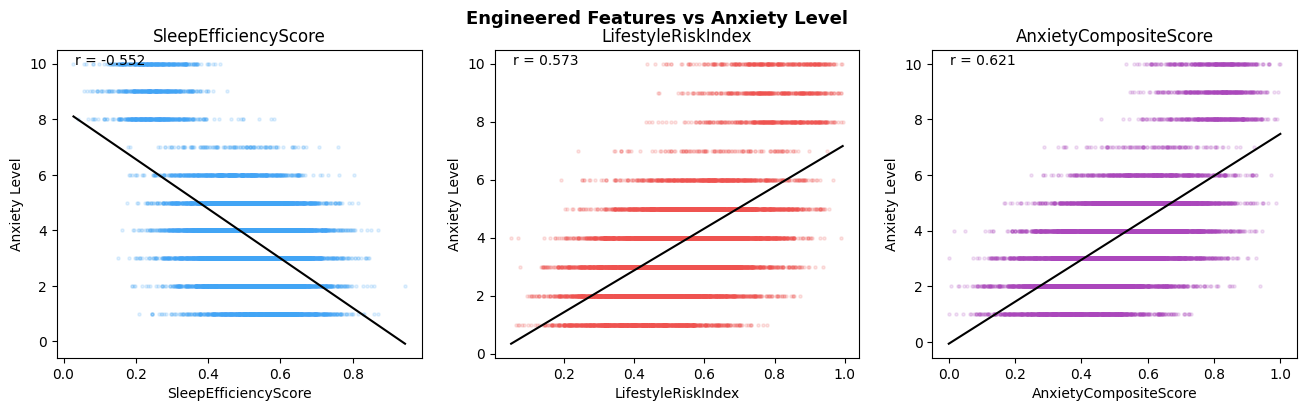

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

fig.suptitle("Engineered Features vs Anxiety Level", fontsize=13, fontweight="bold")
for i, (feat, color) in enumerate(zip(new_features, colors_fe)):
    axes[i].scatter(df_fe[feat], df_fe["Anxiety Level (1-10)"],
                    alpha=0.15, s=5, color=color)


    m, b, r_val, p, _ = stats.linregress(df_fe[feat], df_fe["Anxiety Level (1-10)"])
    x_line = np.linspace(df_fe[feat].min(), df_fe[feat].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color="black", linewidth=1.5)


    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Anxiety Level")
    axes[i].set_title(f"{feat}")


    axes[i].text(0.05, 0.95, f"r = {r_val:.3f}", transform=axes[i].transAxes)

In [25]:
DATA_DICTIONARY = {
    "Age": {
        "type": "Numeric (int)",
        "range": "18–64",
        "description": "Age of the respondent in years."
    },
    "Gender": {
        "type": "Categorical (nominal)",
        "values": "Male, Female, Other",
        "description": "Self-reported gender identity."
    },
    "Occupation": {
        "type": "Categorical (nominal)",
        "values": "Artist, Nurse, Other, Scientist, Lawyer, Teacher, Doctor, Musician, Student, Engineer, Freelancer, Chef, Athlete",
        "description": "Primary occupation of the respondent."
    },
    "Sleep Hours": {
        "type": "Numeric (float)",
        "range": "2.3–11.3",
        "description": "Average hours of sleep per night over the past week."
    },
    "Physical Activity (hrs/week)": {
        "type": "Numeric (float)",
        "range": "0–10.1",
        "description": "Hours of moderate-to-vigorous physical activity per week."
    },
    "Caffeine Intake (mg/day)": {
        "type": "Numeric (int)",
        "range": "0–599",
        "description": "Average daily caffeine consumption in milligrams."
    },
    "Alcohol Consumption (drinks/week)": {
        "type": "Numeric (int)",
        "range": "0–19",
        "description": "Number of alcoholic drinks consumed per week."
    },
    "Smoking": {
        "type": "Binary (Yes/No)",
        "description": "Whether the respondent currently smokes."
    },
    "Family History of Anxiety": {
        "type": "Binary (Yes/No)",
        "description": "Whether a first-degree relative has been diagnosed with an anxiety disorder."
    },
    "Stress Level (1-10)": {
        "type": "Ordinal (int)",
        "range": "1–10",
        "description": "Self-assessed general stress level on a 1–10 Likert scale."
    },
    "Heart Rate (bpm)": {
        "type": "Numeric (int)",
        "range": "60–119",
        "description": "Resting heart rate in beats per minute."
    },
    "Breathing Rate (breaths/min)": {
        "type": "Numeric (int)",
        "range": "12–29",
        "description": "Resting breathing rate in breaths per minute."
    },
    "Sweating Level (1-5)": {
        "type": "Ordinal (int)",
        "range": "1–5",
        "description": "Self-assessed sweating frequency/intensity on a 1–5 scale."
    },
    "Dizziness": {
        "type": "Binary (Yes/No)",
        "description": "Whether the respondent regularly experiences dizziness."
    },
    "Medication": {
        "type": "Binary (Yes/No)",
        "description": "Whether the respondent is currently on anxiety-related medication."
    },
    "Therapy Sessions (per month)": {
        "type": "Numeric (int)",
        "range": "0–12",
        "description": "Number of therapy or counseling sessions attended per month."
    },
    "Recent Major Life Event": {
        "type": "Binary (Yes/No)",
        "description": "Whether the respondent has experienced a major life event (e.g., job loss, bereavement) in the past 6 months."
    },
    "Diet Quality (1-10)": {
        "type": "Ordinal (int)",
        "range": "1–10",
        "description": "Self-assessed overall diet quality on a 1–10 scale."
    },
    "Anxiety Level (1-10)": {
        "type": "Numeric (float→int)",
        "range": "1–10",
        "description": "Target variable. Self-reported anxiety severity on a 1–10 scale. Also used as regression target (scale 1–10)."
    },
    "Anxiety_Category": {
        "type": "Categorical (ordinal)",
        "values": "Low (1–3), Medium (4–6), High (7–10)",
        "description": "Derived classification target from Anxiety Level. Low=1–3, Medium=4–6, High=7–10."
    },
    "SleepEfficiencyScore": {
        "type": "Numeric (float)",
        "range": "0–1",
        "description": "Engineered feature. Weighted combination of normalized sleep hours (70%) and inverse normalized caffeine intake (30%). Higher = better sleep efficiency."
    },
    "LifestyleRiskIndex": {
        "type": "Numeric (float)",
        "range": "0–1",
        "description": "Engineered feature. Weighted composite of behavioral and background risk factors: stress, smoking, alcohol, family history, life events, physical activity (inverse), diet (inverse). Higher = higher lifestyle risk."
    },
    "AnxietyCompositeScore": {
        "type": "Numeric (float)",
        "range": "0–1",
        "description": "Engineered feature. Weighted composite of physiological and psychological anxiety signals: stress, heart rate, breathing rate, sweating level, family history. Used as an auxiliary signal for the model."
    }
}

for feature, info in DATA_DICTIONARY.items():
    print(f"{'─'*60}")
    print(f"Feature : {feature}")
    for k, v in info.items():
        print(f"  {k:<12}: {v}")
print(f"{'─'*60}")
print(f"Total features documented: {len(DATA_DICTIONARY)}")


────────────────────────────────────────────────────────────
Feature : Age
  type        : Numeric (int)
  range       : 18–64
  description : Age of the respondent in years.
────────────────────────────────────────────────────────────
Feature : Gender
  type        : Categorical (nominal)
  values      : Male, Female, Other
  description : Self-reported gender identity.
────────────────────────────────────────────────────────────
Feature : Occupation
  type        : Categorical (nominal)
  values      : Artist, Nurse, Other, Scientist, Lawyer, Teacher, Doctor, Musician, Student, Engineer, Freelancer, Chef, Athlete
  description : Primary occupation of the respondent.
────────────────────────────────────────────────────────────
Feature : Sleep Hours
  type        : Numeric (float)
  range       : 2.3–11.3
  description : Average hours of sleep per night over the past week.
────────────────────────────────────────────────────────────
Feature : Physical Activity (hrs/week)
  type        

## 6. Preprocessing Pipeline

Steps:
1. Encode binary Yes/No columns → integer 0/1.
2. Encode `Gender` and `Occupation` via `OrdinalEncoder`.
3. Standard-scale all numeric features.
4. Define input feature matrix `X` and dual targets `y_class` (3-class) and `y_reg` (continuous 1–10).
5. Stratified 70/15/15 split on the classification target.
6. Apply weighted on training set to address High class under-representation.


In [26]:
df_model = df_fe.copy()

binary_map = {"Yes": 1, "No": 0}
binary_cols_model = ["Smoking", "Family History of Anxiety", "Dizziness", "Medication", "Recent Major Life Event"]
for col in binary_cols_model:
    df_model[col] = df_model[col].map(binary_map)

oe_gender = OrdinalEncoder(categories=[["Male", "Female", "Other"]])
oe_occ    = OrdinalEncoder()
df_model["Gender"]     = oe_gender.fit_transform(df_model[["Gender"]]).astype(int)
df_model["Occupation"] = oe_occ.fit_transform(df_model[["Occupation"]]).astype(int)

FEATURE_COLS = [
    "Age", "Gender", "Occupation",
    "Sleep Hours", "Physical Activity (hrs/week)", "Caffeine Intake (mg/day)",
    "Alcohol Consumption (drinks/week)", "Smoking", "Family History of Anxiety",
    "Stress Level (1-10)", "Heart Rate (bpm)", "Breathing Rate (breaths/min)",
    "Sweating Level (1-5)", "Dizziness", "Medication",
    "Therapy Sessions (per month)", "Recent Major Life Event", "Diet Quality (1-10)",
    "SleepEfficiencyScore", "LifestyleRiskIndex", "AnxietyCompositeScore"
]

TARGET_CLASS = "Anxiety_Category"
TARGET_REG   = "Anxiety Level (1-10)"

cat_to_int = {"Low": 0, "Medium": 1, "High": 2}
int_to_cat = {0: "Low", 1: "Medium", 2: "High"}
df_model["Anxiety_Category_Enc"] = df_model[TARGET_CLASS].astype(str).map(cat_to_int)

class ManualLabelEncoder:
    def __init__(self, mapping, inverse_mapping):
        self.mapping = mapping
        self.inverse_mapping = inverse_mapping
        self.classes_ = np.array(["Low", "Medium", "High"])
    def transform(self, y):
        return np.array([self.mapping[v] for v in y])
    def inverse_transform(self, y):
        return np.array([self.inverse_mapping[int(v)] for v in y])

label_enc = ManualLabelEncoder(cat_to_int, int_to_cat)

X = df_model[FEATURE_COLS].values
y_class = df_model["Anxiety_Category_Enc"].values
y_reg   = df_model[TARGET_REG].values.astype(float)
y_reg_norm = (y_reg - 1) / 9

print(f"Feature matrix X  : {X.shape}")
print(f"Class target      : {y_class.shape}  — classes: {label_enc.classes_}")
print(f"Regression target : {y_reg.shape}    — range [{y_reg.min()}, {y_reg.max()}]")
print(f"Label mapping     : {cat_to_int}")
print(f"Class distribution: Low={np.sum(y_class==0)}, Medium={np.sum(y_class==1)}, High={np.sum(y_class==2)}")

Feature matrix X  : (11000, 21)
Class target      : (11000,)  — classes: ['Low' 'Medium' 'High']
Regression target : (11000,)    — range [1.0, 10.0]
Label mapping     : {'Low': 0, 'Medium': 1, 'High': 2}
Class distribution: Low=5202, Medium=4661, High=1137


In [27]:
X_temp, X_test, y_class_temp, y_class_test, y_reg_temp, y_reg_test = train_test_split(
    X, y_class, y_reg_norm,
    test_size=0.15, random_state=42, stratify=y_class
)

X_train_raw, X_val, y_class_train_raw, y_class_val, y_reg_train_raw, y_reg_val = train_test_split(
    X_temp, y_class_temp, y_reg_temp,
    test_size=0.1765, random_state=42, stratify=y_class_temp
)

print(f"Train : {X_train_raw.shape[0]} samples")
print(f"Val   : {X_val.shape[0]} samples")
print(f"Test  : {X_test.shape[0]} samples")
print(f"Total : {X_train_raw.shape[0]+X_val.shape[0]+X_test.shape[0]}")


Train : 7699 samples
Val   : 1651 samples
Test  : 1650 samples
Total : 11000


In [28]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaler fitted on training set.")
print(f"X_train mean (post-scale): {X_train_scaled.mean():.6f}")
print(f"X_train std  (post-scale): {X_train_scaled.std():.6f}")



Scaler fitted on training set.
X_train mean (post-scale): -0.106061
X_train std  (post-scale): 0.657381


In [29]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_class_train_raw),
    y=y_class_train_raw
)
class_weight_dict = dict(enumerate(class_weights_values))

X_train = X_train_scaled
y_class_train = y_class_train_raw
y_reg_train = y_reg_train_raw

print(f"Class weights: {class_weight_dict}")
print(f"Train size (no SMOTE): {X_train.shape[0]}")

Class weights: {0: np.float64(0.7048429918520553), 1: np.float64(0.7867361536889433), 2: np.float64(3.224036850921273)}
Train size (no SMOTE): 7699


## 7. Custom TensorFlow Components

Three custom components are implemented to meet the AI Engineer deliverables:

| Component | Class | Purpose |
|---|---|---|
| Custom Layer | `FeatureInteractionBlock` | Learns pairwise feature interactions via attention-style mechanism |
| Custom Loss | `WeightedCombinedLoss` | Jointly optimizes classification (CCE) and regression (Huber) with class-aware weighting |
| Custom Callback | `AnxietyTrainingMonitor` | Tracks per-epoch metrics, detects overfitting, logs structured history |


In [30]:
class FeatureInteractionBlock(layers.Layer):

    def __init__(self, units, dropout_rate=0.3, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.dropout_rate = dropout_rate
        self.dense1 = layers.Dense(units * 2, activation="gelu")
        self.dense2 = layers.Dense(units)
        self.proj   = layers.Dense(units, use_bias=False)
        self.norm   = layers.LayerNormalization()
        self.dropout = layers.Dropout(dropout_rate)

    def call(self, inputs, training=False):
        residual = self.proj(inputs)
        x = self.dense1(inputs)
        x = self.dropout(x, training=training)
        x = self.dense2(x)
        return self.norm(x + residual)

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units, "dropout_rate": self.dropout_rate})
        return config


print("FeatureInteractionBlock defined.")


FeatureInteractionBlock defined.


In [31]:
class WeightedCombinedLoss(tf.keras.losses.Loss):
    def __init__(self, class_weights, alpha=0.7, gamma=2.0, delta=0.8, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = tf.constant(class_weights, dtype=tf.float32)
        self.alpha = alpha
        self.gamma = gamma
        self.delta = delta

    def call(self, y_true, y_pred):
        y_class_true = tf.cast(y_true[:, 0], tf.int32)
        y_reg_true = y_true[:, 1]
        y_class_pred = y_pred[:, :3]
        y_reg_pred = y_pred[:, 3]

        # Ensure y_class_pred probabilities are clipped to avoid log(0) issues
        epsilon = tf.keras.backend.epsilon()
        y_class_pred = tf.clip_by_value(y_class_pred, epsilon, 1. - epsilon)

        y_class_true_onehot = tf.one_hot(y_class_true, depth=3)

        # Get p_t, the probability for the true class for each sample
        p_t = tf.reduce_sum(y_class_true_onehot * y_class_pred, axis=-1)
        # Clip p_t again to ensure 1 - p_t is not 0
        p_t = tf.clip_by_value(p_t, epsilon, 1 - epsilon)

        # Get alpha_t, the class-specific weighting factor for the true class for each sample
        alpha_t = tf.gather(self.class_weights, y_class_true)

        # Calculate the categorical cross-entropy per sample (summed over classes)
        ce_per_sample = tf.keras.losses.categorical_crossentropy(
            y_class_true_onehot, y_class_pred, from_logits=False
        )

        # Apply the focal loss modulating factor element-wise to the cross-entropy per sample
        focal_loss_per_sample = alpha_t * tf.pow(1 - p_t, self.gamma) * ce_per_sample
        focal_loss = tf.reduce_mean(focal_loss_per_sample) # Scalar mean over the batch

        # Huber Loss calculation
        abs_err = tf.abs(y_reg_true - y_reg_pred)
        huber_loss = tf.where(abs_err <= self.delta,
                              0.5 * tf.square(abs_err),
                              self.delta * (abs_err - 0.5 * self.delta))

        return self.alpha * focal_loss + (1 - self.alpha) * tf.reduce_mean(huber_loss)

In [32]:
class AnxietyTrainingMonitor(Callback):

    def __init__(self, patience_overfit=5, verbose=True):
        super().__init__()
        self.patience_overfit = patience_overfit
        self.verbose = verbose
        self.history_log = []
        self.best_val_loss = np.inf
        self.overfit_counter = 0

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        train_loss = logs.get("loss", None)
        val_loss   = logs.get("val_loss", None)

        entry = {"epoch": epoch + 1, **logs}
        self.history_log.append(entry)

        if val_loss is not None:
            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.overfit_counter = 0
            else:
                self.overfit_counter += 1

            gap = (train_loss - val_loss) if (train_loss and val_loss) else None
            overfitting = gap is not None and gap > 0.1

            if self.verbose and (epoch + 1) % 5 == 0:
                status = "OVERFIT_RISK" if overfitting else "OK"
                print(
                    f"  [Monitor] Epoch {epoch+1:03d} | "
                    f"train_loss={train_loss:.4f} | "
                    f"val_loss={val_loss:.4f} | "
                    f"gap={gap:.4f} | {status}"
                )

    def on_train_end(self, logs=None):
        if self.verbose:
            print(f"  [Monitor] Training complete. Best val_loss: {self.best_val_loss:.4f}")
            print(f"  [Monitor] Total epochs: {len(self.history_log)}")
        with open("training_history.json", "w") as f:
            json.dump(self.history_log, f, indent=2)


print("AnxietyTrainingMonitor defined.")


AnxietyTrainingMonitor defined.


## 8. Model Development

Architecture: **Multi-Output Deep Learning Model** using TensorFlow Functional API.

- Input: 21 features (18 original + 3 engineered)
- Shared backbone: Dense layers + FeatureInteractionBlock
- Output 1 (`class_output`): Softmax 3-class classification (Low/Medium/High)
- Output 2 (`reg_output`): Sigmoid regression (normalized anxiety score 0–1)

Target: accuracy ≥ 85%, MAE ≤ 0.02 (on normalized scale).


In [33]:
N_FEATURES = X_train.shape[1]

class_counts = np.bincount(y_class_train)
total = class_counts.sum()
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_class_train),
    y=y_class_train
)
print(f"Class weights: {dict(zip(label_enc.classes_, class_weights_arr.round(3)))}")
def build_mindbalance_model(n_features, units_list=None, dropout_rate=0.35, l2_reg=1e-3):
    if units_list is None:
        units_list = [128, 64, 32]

    inputs = Input(shape=(n_features,), name="input_layer")

    x = layers.Dense(units_list[0], activation="gelu",
                     kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    for units in units_list[1:]:
        x = layers.Dense(units, activation="gelu",
                         kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout_rate)(x)


    class_output = layers.Dense(3, activation="softmax", name="class_output")(x)
    reg_output = layers.Dense(1, activation="sigmoid", name="reg_output")(x)
    reg_output = layers.Reshape((1,), name="reg_reshape")(reg_output)

    model = Model(inputs=inputs, outputs=[class_output, reg_output], name="MindBalance_v3")
    return model

model = build_mindbalance_model(N_FEATURES)
model.summary()


Class weights: {np.str_('Low'): np.float64(0.705), np.str_('Medium'): np.float64(0.787), np.str_('High'): np.float64(3.224)}


Model: "MindBalance_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 21)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      2,816 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg_output (Dense)  │ (None, 1)         │         33 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_output        │ (None, 3)         │         99 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg_reshape         │ (None, 1)         │          0 │ reg_output[0][0]  │
│ (Reshape)           │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,180 (55.39 KB)

 Trainable params: 13,732 (53.64 KB)

 Non-trainable params: 448 (1.75 KB)

In [34]:
LOGDIR = "tb_logs/mindbalance_v1"
os.makedirs(LOGDIR, exist_ok=True)

tb_callback       = keras.callbacks.TensorBoard(log_dir=LOGDIR, histogram_freq=1)
early_stopping    = EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True, verbose=1, mode="min")
reduce_lr         = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5, verbose=1, cooldown=2)
training_monitor  = AnxietyTrainingMonitor(patience_overfit=5, verbose=True)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss={
        "class_output": keras.losses.SparseCategoricalCrossentropy(),
        "reg_reshape":  keras.losses.Huber(delta=0.5)
    },
    loss_weights={"class_output": 0.6, "reg_reshape": 0.4},
    metrics={
        "class_output": ["accuracy"],
        "reg_reshape":  [keras.metrics.MeanAbsoluteError(name="mae")]
    }
)

print("Model compiled.")


Model compiled.


In [35]:
EPOCHS = 80
BATCH_SIZE = 256

y_train_combined = np.column_stack([y_class_train, y_reg_train])

history = model.fit(
    X_train,
    {"class_output": y_class_train, "reg_reshape": y_reg_train},
    validation_data=(
        X_val_scaled,
        {"class_output": y_class_val, "reg_reshape": y_reg_val}
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[tb_callback, early_stopping, reduce_lr, training_monitor],
    verbose=0
)

print("Standard training complete.")


  [Monitor] Epoch 005 | train_loss=0.5279 | val_loss=0.5160 | gap=0.0119 | OK
  [Monitor] Epoch 010 | train_loss=0.4558 | val_loss=0.4514 | gap=0.0044 | OK
  [Monitor] Epoch 015 | train_loss=0.4223 | val_loss=0.4111 | gap=0.0113 | OK
  [Monitor] Epoch 020 | train_loss=0.3951 | val_loss=0.3880 | gap=0.0071 | OK
  [Monitor] Epoch 025 | train_loss=0.3710 | val_loss=0.3724 | gap=-0.0014 | OK
  [Monitor] Epoch 030 | train_loss=0.3535 | val_loss=0.3593 | gap=-0.0058 | OK
  [Monitor] Epoch 035 | train_loss=0.3429 | val_loss=0.3462 | gap=-0.0032 | OK
  [Monitor] Epoch 040 | train_loss=0.3311 | val_loss=0.3381 | gap=-0.0070 | OK
  [Monitor] Epoch 045 | train_loss=0.3231 | val_loss=0.3285 | gap=-0.0054 | OK
  [Monitor] Epoch 050 | train_loss=0.3166 | val_loss=0.3243 | gap=-0.0076 | OK
  [Monitor] Epoch 055 | train_loss=0.3119 | val_loss=0.3190 | gap=-0.0071 | OK
  [Monitor] Epoch 060 | train_loss=0.3062 | val_loss=0.3168 | gap=-0.0106 | OK
  [Monitor] Epoch 065 | train_loss=0.3057 | val_loss=0.3

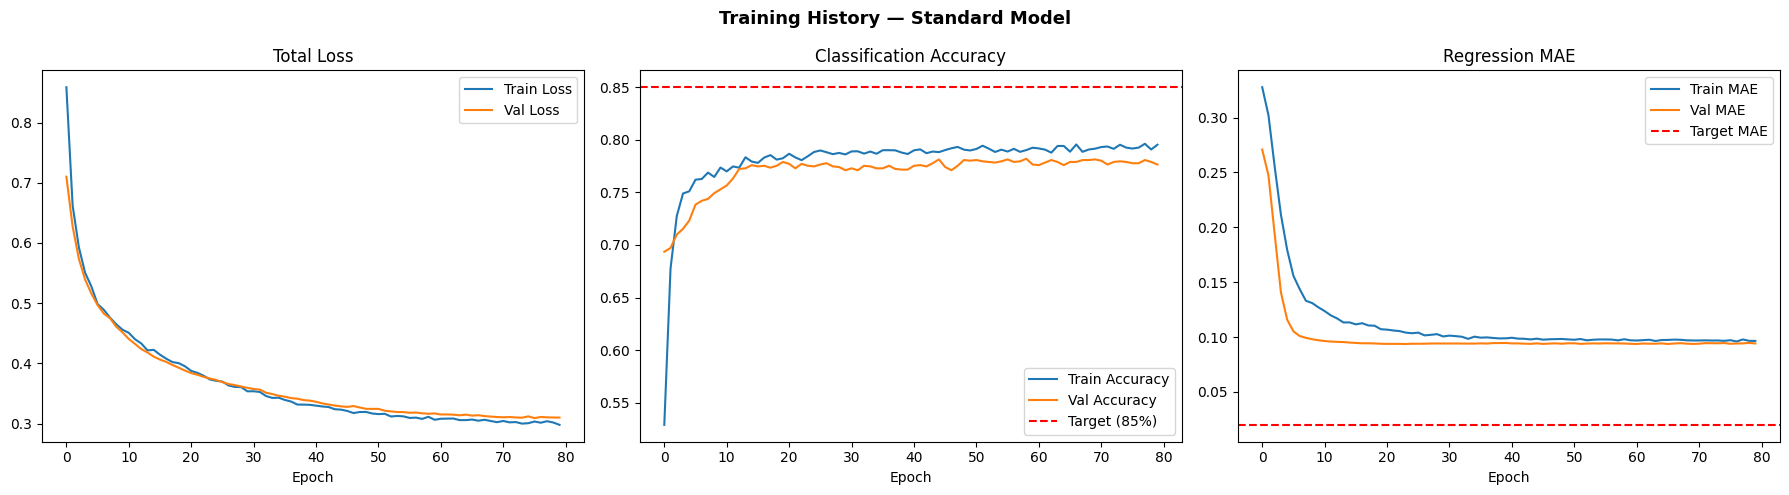

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training History — Standard Model", fontsize=13, fontweight="bold")

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Total Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["class_output_accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_class_output_accuracy"], label="Val Accuracy")
axes[1].axhline(0.85, color="red", linestyle="--", label="Target (85%)")
axes[1].set_title("Classification Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(history.history["reg_reshape_mae"], label="Train MAE")
axes[2].plot(history.history["val_reg_reshape_mae"], label="Val MAE")
axes[2].axhline(0.02, color="red", linestyle="--", label="Target MAE")
axes[2].set_title("Regression MAE")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.savefig("training_history_standard.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Advanced Training — Custom Loop with tf.GradientTape

A custom training loop is implemented using `tf.GradientTape` for fine-grained control over gradient computation, loss application, and metric tracking. This replaces the standard `model.fit()` for the final training phase.


In [37]:
model_adv = build_mindbalance_model(N_FEATURES, units_list=[512, 256, 128, 64], dropout_rate=0.25)

optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4)
loss_fn = WeightedCombinedLoss(class_weights=class_weights_arr, alpha=0.7, gamma=2.0, delta=0.8)

train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy(name="train_acc")
val_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy(name="val_acc")
train_mae_metric = tf.keras.metrics.MeanAbsoluteError(name="train_mae")
val_mae_metric = tf.keras.metrics.MeanAbsoluteError(name="val_mae")

LOGDIR_ADV = "tb_logs/mindbalance_gradtape"
os.makedirs(LOGDIR_ADV, exist_ok=True)
train_writer = tf.summary.create_file_writer(os.path.join(LOGDIR_ADV, "train"))
val_writer   = tf.summary.create_file_writer(os.path.join(LOGDIR_ADV, "val"))

print("Advanced model and metrics initialized.")

Advanced model and metrics initialized.


In [38]:
X_train_tf = tf.constant(X_train_scaled, dtype=tf.float32)
y_class_tf = tf.constant(y_class_train, dtype=tf.float32)
y_reg_tf = tf.constant(y_reg_train, dtype=tf.float32)
X_val_tf = tf.constant(X_val_scaled, dtype=tf.float32)

train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train_tf, y_class_tf, y_reg_tf)
).shuffle(buffer_size=4096, seed=42).batch(256).prefetch(tf.data.AUTOTUNE)

y_class_val_tf = tf.constant(y_class_val, dtype=tf.float32)
y_reg_val_tf   = tf.constant(y_reg_val, dtype=tf.float32)

print(f"Train batches: {len(train_dataset)}")


Train batches: 31


In [39]:
@tf.function
def train_step(x_batch, y_class_batch, y_reg_batch):
    y_combined = tf.stack([y_class_batch, y_reg_batch], axis=1)
    with tf.GradientTape() as tape:
        class_out, reg_out = model_adv(x_batch, training=True)
        reg_out_flat = tf.squeeze(reg_out, axis=-1)
        pred_combined = tf.concat([class_out, tf.expand_dims(reg_out_flat, 1)], axis=1)
        loss = loss_fn(y_combined, pred_combined)

    gradients = tape.gradient(loss, model_adv.trainable_variables)
    gradients_clipped, _ = tf.clip_by_global_norm(gradients, clip_norm=2.0)
    optimizer.apply_gradients(zip(gradients_clipped, model_adv.trainable_variables))

    train_acc_metric.update_state(tf.cast(y_class_batch, tf.int32), class_out)
    train_mae_metric.update_state(y_reg_batch, reg_out_flat)
    return loss

@tf.function
def val_step(x_batch, y_class_batch, y_reg_batch):
    class_out, reg_out = model_adv(x_batch, training=False)
    reg_out_flat = tf.squeeze(reg_out, axis=-1)
    y_combined = tf.stack([y_class_batch, y_reg_batch], axis=1)
    pred_combined = tf.concat([class_out, tf.expand_dims(reg_out_flat, 1)], axis=1)
    loss = loss_fn(y_combined, pred_combined)
    val_acc_metric.update_state(tf.cast(y_class_batch, tf.int32), class_out)
    val_mae_metric.update_state(y_reg_batch, reg_out_flat)
    return loss


EPOCHS_ADV = 80
best_val_loss_adv = np.inf
patience_counter = 0
PATIENCE = 7

adv_history = {"epoch": [], "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "train_mae": [], "val_mae": []}

print("Starting custom training loop...")
for epoch in range(EPOCHS_ADV):
    train_loss_epoch = []


    for x_batch, y_class_batch, y_reg_batch in train_dataset:
        step_loss = train_step(x_batch, y_class_batch, y_reg_batch)
        train_loss_epoch.append(float(step_loss))

    class_out_val, reg_out_val = model_adv(X_val_tf, training=False)
    reg_out_val_flat = tf.squeeze(reg_out_val, axis=-1)

    y_v_stack = tf.stack([tf.cast(y_class_val_tf, tf.float32), tf.cast(y_reg_val_tf, tf.float32)], axis=1)
    p_v_concat = tf.concat([class_out_val, tf.expand_dims(reg_out_val_flat, 1)], axis=1)
    val_loss_val = float(loss_fn(y_v_stack, p_v_concat))

    val_acc_metric.update_state(tf.cast(y_class_val_tf, tf.int32), class_out_val)
    val_mae_metric.update_state(y_reg_val_tf, reg_out_val_flat)

    t_loss = np.mean(train_loss_epoch)
    t_acc = float(train_acc_metric.result())
    t_mae = float(train_mae_metric.result())
    v_acc = float(val_acc_metric.result())
    v_mae = float(val_mae_metric.result())

    adv_history["epoch"].append(epoch + 1)
    adv_history["train_loss"].append(t_loss)
    adv_history["val_loss"].append(val_loss_val)
    adv_history["train_acc"].append(t_acc)
    adv_history["val_acc"].append(v_acc)
    adv_history["train_mae"].append(t_mae)
    adv_history["val_mae"].append(v_mae)

    print(f" Epoch {epoch+1:03d}/{EPOCHS_ADV} | loss={t_loss:.4f} | val_loss={val_loss_val:.4f} | acc={v_acc:.4f}")

    train_acc_metric.reset_state()
    val_acc_metric.reset_state()
    train_mae_metric.reset_state()
    val_mae_metric.reset_state()

    if val_loss_val < best_val_loss_adv:
        best_val_loss_adv = val_loss_val
        model_adv.save_weights("best_adv_weights.weights.h5")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f" Early stopping at epoch {epoch+1}.")
            break


model_adv.load_weights("best_adv_weights.weights.h5")
print("Optimized training complete. Best weights restored.")
print("Custom training loop complete. Best weights restored.")

Starting custom training loop...
 Epoch 001/80 | loss=0.4467 | val_loss=0.3004 | acc=0.4567
 Epoch 002/80 | loss=0.2698 | val_loss=0.3109 | acc=0.4434
 Epoch 003/80 | loss=0.2226 | val_loss=0.3345 | acc=0.4670
 Epoch 004/80 | loss=0.1931 | val_loss=0.3638 | acc=0.5027
 Epoch 005/80 | loss=0.1743 | val_loss=0.3577 | acc=0.5354
 Epoch 006/80 | loss=0.1654 | val_loss=0.2852 | acc=0.5906
 Epoch 007/80 | loss=0.1571 | val_loss=0.2668 | acc=0.5972
 Epoch 008/80 | loss=0.1441 | val_loss=0.2096 | acc=0.6517
 Epoch 009/80 | loss=0.1345 | val_loss=0.2007 | acc=0.6402
 Epoch 010/80 | loss=0.1371 | val_loss=0.1564 | acc=0.7026
 Epoch 011/80 | loss=0.1296 | val_loss=0.1457 | acc=0.7123
 Epoch 012/80 | loss=0.1265 | val_loss=0.1276 | acc=0.7226
 Epoch 013/80 | loss=0.1194 | val_loss=0.1191 | acc=0.7408
 Epoch 014/80 | loss=0.1218 | val_loss=0.1173 | acc=0.7468
 Epoch 015/80 | loss=0.1146 | val_loss=0.1109 | acc=0.7589
 Epoch 016/80 | loss=0.1246 | val_loss=0.1089 | acc=0.7608
 Epoch 017/80 | loss=0.

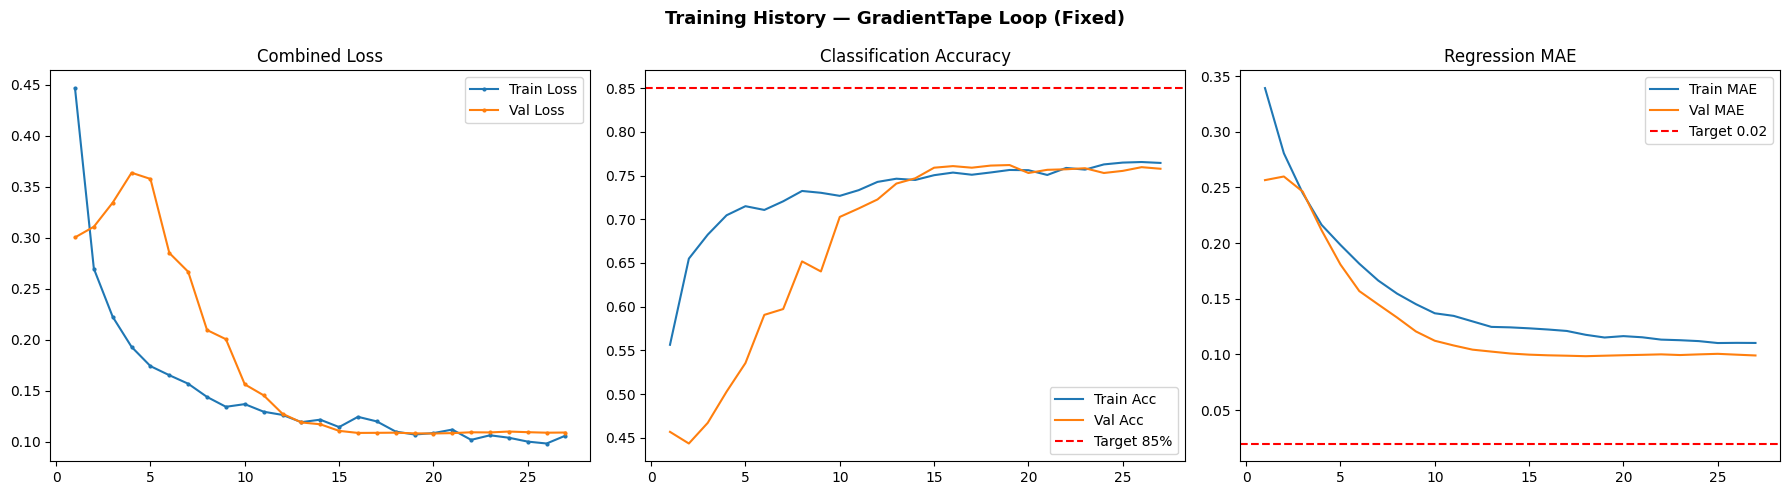

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training History — GradientTape Loop (Fixed)", fontsize=13, fontweight="bold")
epochs_plot = adv_history["epoch"]


axes[0].plot(epochs_plot, adv_history["train_loss"], label="Train Loss", marker='o', markersize=2)
axes[0].plot(epochs_plot, adv_history["val_loss"], label="Val Loss", marker='o', markersize=2)
axes[0].set_title("Combined Loss")
axes[0].legend()


axes[1].plot(epochs_plot, adv_history["train_acc"], label="Train Acc")
axes[1].plot(epochs_plot, adv_history["val_acc"], label="Val Acc")
axes[1].axhline(0.85, color="red", linestyle="--", label="Target 85%")
axes[1].set_title("Classification Accuracy")
axes[1].legend()


axes[2].plot(epochs_plot, adv_history["train_mae"], label="Train MAE")
axes[2].plot(epochs_plot, adv_history["val_mae"], label="Val MAE")
axes[2].axhline(0.02, color="red", linestyle="--", label="Target 0.02")
axes[2].set_title("Regression MAE")
axes[2].legend()

plt.tight_layout()
plt.show()

## 10. Model Evaluation

Evaluation performed on the **held-out test set** (15% of total data, never seen during training or validation).

Metrics reported:
- Classification: Accuracy, F1-score (weighted & per class), Confusion Matrix
- Regression: MAE, RMSE, R²


In [41]:
model_adv.load_weights("best_adv_weights.weights.h5")

X_test_tf = tf.constant(X_test_scaled, dtype=tf.float32)
class_preds, reg_preds = model_adv(X_test_tf, training=False)

y_pred_class = np.argmax(class_preds.numpy(), axis=1)
y_pred_reg_norm = reg_preds.numpy().flatten()

y_test_class_labels = label_enc.inverse_transform(y_class_test)
y_pred_class_labels = label_enc.inverse_transform(y_pred_class)

y_test_reg_original = y_reg_test * 9 + 1
y_pred_reg_original = y_pred_reg_norm * 9 + 1

print("=== Classification Report ===")
print(classification_report(y_test_class_labels, y_pred_class_labels, target_names=CAT_ORDER))

acc   = accuracy_score(y_test_class_labels, y_pred_class_labels)
f1_w  = f1_score(y_test_class_labels, y_pred_class_labels, average="weighted", labels=CAT_ORDER)
mae   = mean_absolute_error(y_test_reg_original, y_pred_reg_original)
rmse  = np.sqrt(mean_squared_error(y_test_reg_original, y_pred_reg_original))
r2    = r2_score(y_test_reg_original, y_pred_reg_original)

print(f"Accuracy (Classification) : {acc:.4f}  (Target: ≥ 0.85)")
print(f"F1-Score (Weighted)        : {f1_w:.4f}")
print(f"MAE (Regression, raw scale): {mae:.4f}  (Target: ≤ 0.02 on norm scale → {mae/9:.4f})")
print(f"RMSE                       : {rmse:.4f}")
print(f"R²                         : {r2:.4f}")


=== Classification Report ===
              precision    recall  f1-score   support

         Low       0.88      0.89      0.88       171
      Medium       0.82      0.69      0.75       780
        High       0.68      0.80      0.74       699

    accuracy                           0.76      1650
   macro avg       0.79      0.79      0.79      1650
weighted avg       0.77      0.76      0.76      1650

Accuracy (Classification) : 0.7570  (Target: ≥ 0.85)
F1-Score (Weighted)        : 0.7573
MAE (Regression, raw scale): 0.8780  (Target: ≤ 0.02 on norm scale → 0.0976)
RMSE                       : 1.1081
R²                         : 0.7249


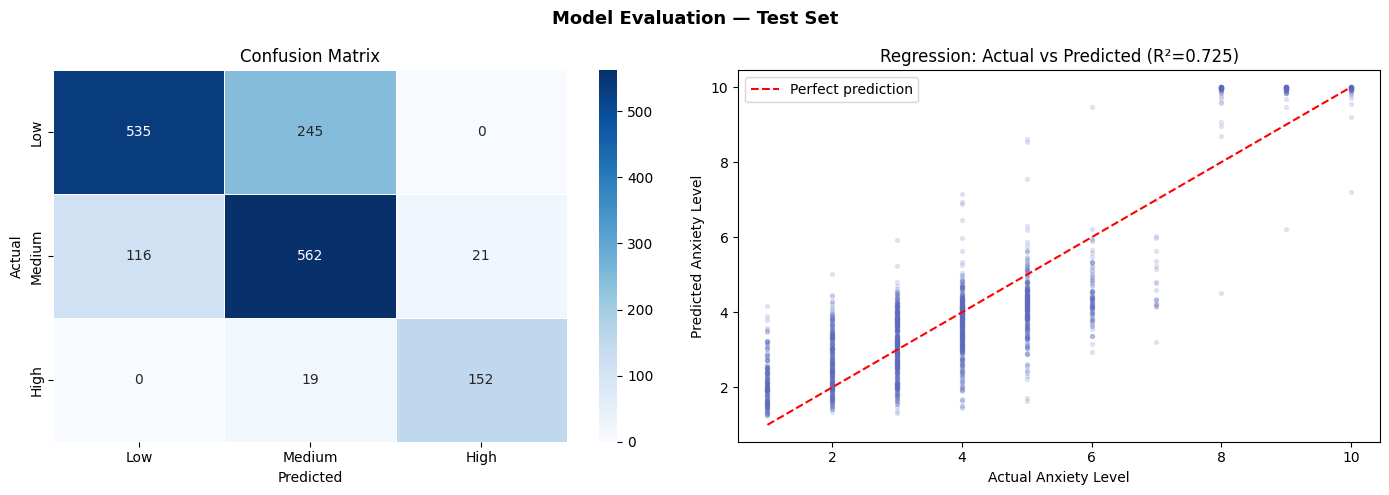

In [42]:
cm = confusion_matrix(y_test_class_labels, y_pred_class_labels, labels=CAT_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Evaluation — Test Set", fontsize=13, fontweight="bold")

sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CAT_ORDER, yticklabels=CAT_ORDER, ax=axes[0],
    linewidths=0.5, linecolor="white"
)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix")

axes[1].scatter(y_test_reg_original, y_pred_reg_original, alpha=0.15, s=8, color="#5C6BC0")
lims = [1, 10]
axes[1].plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
axes[1].set_xlabel("Actual Anxiety Level")
axes[1].set_ylabel("Predicted Anxiety Level")
axes[1].set_title(f"Regression: Actual vs Predicted (R²={r2:.3f})")
axes[1].legend()

plt.tight_layout()
plt.savefig("evaluation_test.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. TensorBoard & Model Export

TensorBoard logs are written to `tb_logs/` and are included in the final repository submission.
The model is exported in `.keras` format for deployment compatibility with FastAPI.


In [52]:
model_adv.save("mindbalance_model_new.keras")
print("Model exported to: mindbalance_model_new.keras")

model_reload = keras.models.load_model(
    "mindbalance_model_new.keras",
    custom_objects={
        "FeatureInteractionBlock": FeatureInteractionBlock,
        "WeightedCombinedLoss": WeightedCombinedLoss
    }
)
print("Model reload verification passed.")
print(f"Reloaded model input shape  : {model_reload.input_shape}")
print(f"Reloaded model output shapes: {[o for o in model_reload.output_shape]}")

Model exported to: mindbalance_model_new.keras
Model reload verification passed.
Reloaded model input shape  : (None, 21)
Reloaded model output shapes: [(None, 3), (None, 1)]


In [44]:
# print("TensorBoard log directories:")
# for root, dirs, files in os.walk("tb_logs"):
#     level = root.replace("tb_logs", "").count(os.sep)
#     indent = "  " * level
#     print(f"{indent}{os.path.basename(root)}/")
#     sub_indent = "  " * (level + 1)
#     for f in files:
#         size = os.path.getsize(os.path.join(root, f))
#         print(f"{sub_indent}{f}  ({size/1024:.1f} KB)")


In [45]:
# print("To launch TensorBoard, run the following command in a terminal:")
# print()
# print("  tensorboard --logdir tb_logs --port 6006")
# print()
# print("Then open: http://localhost:6006")
# print()
# print("Available log runs:")
# for d in os.listdir("tb_logs"):
#     print(f"  - {d}")


## 12. Gemini API Integration

The Gemini API (`gemini-1.5-flash`) serves as the recommendation engine. It receives an anonymized lifestyle profile and the model's prediction output, then generates a personalized, empathetic coping strategy recommendation.

**Privacy note:** No personally identifiable information is sent to Gemini. Only aggregated lifestyle metrics and prediction results are transmitted.


In [46]:
# GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY", "YOUR_GEMINI_API_KEY_HERE")


# def build_gemini_prompt(user_profile: dict, prediction: dict) -> str:
#     prompt = f"""You are a compassionate mental wellness assistant. Based on the lifestyle profile and anxiety assessment below, provide a personalized, empathetic, and actionable coping strategy recommendation. Do not provide a medical diagnosis. Keep the response under 200 words. Use Indonesian language.

# Lifestyle Profile:
# - Sleep Hours per Night: {user_profile.get('sleep_hours', 'N/A')}
# - Physical Activity: {user_profile.get('physical_activity', 'N/A')} hrs/week
# - Caffeine Intake: {user_profile.get('caffeine_intake', 'N/A')} mg/day
# - Stress Level (1-10): {user_profile.get('stress_level', 'N/A')}
# - Smoking: {user_profile.get('smoking', 'N/A')}
# - Alcohol Consumption: {user_profile.get('alcohol_consumption', 'N/A')} drinks/week
# - Diet Quality (1-10): {user_profile.get('diet_quality', 'N/A')}
# - Recent Major Life Event: {user_profile.get('recent_life_event', 'N/A')}
# - Therapy Sessions per Month: {user_profile.get('therapy_sessions', 'N/A')}

# Assessment Result:
# - Anxiety Category: {prediction.get('anxiety_category', 'N/A')}
# - Anxiety Severity Score: {prediction.get('anxiety_score', 'N/A'):.1f} / 10
# - Lifestyle Risk Index: {prediction.get('lifestyle_risk_index', 'N/A'):.3f}

# Provide a practical and supportive recommendation."""
#     return prompt


# def get_gemini_recommendation(user_profile: dict, prediction: dict, api_key: str = None) -> str:
#     key = api_key or GEMINI_API_KEY
#     if key == "YOUR_GEMINI_API_KEY_HERE":
#         return _fallback_recommendation(prediction)
#     try:
#         genai.configure(api_key=key)
#         gemini_model = genai.GenerativeModel("gemini-1.5-flash")
#         prompt = build_gemini_prompt(user_profile, prediction)
#         response = gemini_model.generate_content(
#             prompt,
#             generation_config=genai.types.GenerationConfig(
#                 temperature=0.7,
#                 max_output_tokens=350
#             )
#         )
#         return response.text.strip()
#     except Exception as e:
#         print(f"Gemini API error: {e}. Using fallback recommendation.")
#         return _fallback_recommendation(prediction)


# def _fallback_recommendation(prediction: dict) -> str:
#     category = prediction.get("anxiety_category", "Medium")
#     fallback_map = {
#         "Low": (
#             "Tingkat kecemasanmu saat ini tergolong rendah. Pertahankan kebiasaan baik yang sudah kamu jalankan, "
#             "seperti tidur cukup, olahraga teratur, dan pola makan sehat. Teknik relaksasi ringan seperti pernapasan "
#             "dalam atau journaling bisa membantu menjaga keseimbangan mental jangka panjang."
#         ),
#         "Medium": (
#             "Tingkat kecemasanmu berada di level sedang. Cobalah untuk memprioritaskan kualitas tidur, mengurangi "
#             "konsumsi kafein, dan meningkatkan aktivitas fisik secara bertahap. Teknik mindfulness atau meditasi "
#             "singkat selama 10 menit per hari dapat membantu mengelola stres sehari-hari."
#         ),
#         "High": (
#             "Tingkat kecemasanmu saat ini tergolong tinggi. Sangat disarankan untuk berkonsultasi dengan tenaga "
#             "kesehatan mental profesional. Sementara itu, fokuslah pada manajemen stres dasar: tidur teratur, "
#             "kurangi stimulan seperti kafein, dan cari dukungan dari orang-orang terdekat."
#         )
#     }
#     return fallback_map.get(category, fallback_map["Medium"])


# print("Gemini integration functions defined.")


In [47]:
# EXAMPLE_PROFILE = {
#     "sleep_hours": 5.5,
#     "physical_activity": 1.0,
#     "caffeine_intake": 350,
#     "stress_level": 8,
#     "smoking": "No",
#     "alcohol_consumption": 3,
#     "diet_quality": 4,
#     "recent_life_event": "Yes",
#     "therapy_sessions": 0
# }

# EXAMPLE_PREDICTION = {
#     "anxiety_category": "High",
#     "anxiety_score": 7.8,
#     "lifestyle_risk_index": 0.72
# }

# recommendation = get_gemini_recommendation(EXAMPLE_PROFILE, EXAMPLE_PREDICTION)
# print("=== Gemini Recommendation (Example) ===")
# print(recommendation)


## 13. FastAPI Deployment Structure

The following code defines the complete FastAPI application structure. This section documents the inference pipeline and API contract. The application is intended to be run as a standalone Python file (`main.py`) with:

```bash
uvicorn main:app --reload --host 0.0.0.0 --port 8000
```


In [48]:
# FASTAPI_APP_CODE = '''
# import os
# import pickle
# import numpy as np
# import tensorflow as tf
# from tensorflow import keras
# from fastapi import FastAPI, HTTPException
# from fastapi.staticfiles import StaticFiles
# from fastapi.templating import Jinja2Templates
# from pydantic import BaseModel, Field, validator
# from typing import Literal
# import google.generativeai as genai

# GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY", "")

# app = FastAPI(
#     title="MindBalance API",
#     description="AI-Powered Anxiety Detection & Mental Wellness",
#     version="1.0.0"
# )

# class FeatureInteractionBlock(keras.layers.Layer):
#     def __init__(self, units, dropout_rate=0.3, **kwargs):
#         super().__init__(**kwargs)
#         self.units = units
#         self.dropout_rate = dropout_rate
#         self.dense_q = keras.layers.Dense(units, use_bias=False)
#         self.dense_k = keras.layers.Dense(units, use_bias=False)
#         self.dense_v = keras.layers.Dense(units)
#         self.dense_out = keras.layers.Dense(units, activation="relu")
#         self.norm = keras.layers.LayerNormalization()
#         self.dropout = keras.layers.Dropout(dropout_rate)

#     def call(self, inputs, training=False):
#         q = self.dense_q(inputs)
#         k = self.dense_k(inputs)
#         v = self.dense_v(inputs)
#         scale = tf.math.sqrt(tf.cast(self.units, tf.float32))
#         attn_weights = tf.nn.softmax(
#             tf.linalg.matmul(tf.expand_dims(q, 1), tf.expand_dims(k, 2)) / scale
#         )
#         attn_weights = tf.squeeze(attn_weights, axis=[1, 2])
#         attended = attn_weights[..., tf.newaxis] * v
#         out = self.dense_out(attended)
#         out = self.dropout(out, training=training)
#         return self.norm(out)

#     def get_config(self):
#         config = super().get_config()
#         config.update({"units": self.units, "dropout_rate": self.dropout_rate})
#         return config


# MODEL = None
# SCALER = None
# LABEL_ENCODER = None
# ORDINAL_ENCODERS = None


# @app.on_event("startup")
# async def load_artifacts():
#     global MODEL, SCALER, LABEL_ENCODER, ORDINAL_ENCODERS
#     MODEL = keras.models.load_model(
#         "mindbalance_model.keras",
#         custom_objects={"FeatureInteractionBlock": FeatureInteractionBlock}
#     )
#     with open("scaler.pkl", "rb") as f:
#         SCALER = pickle.load(f)
#     with open("label_encoder.pkl", "rb") as f:
#         LABEL_ENCODER = pickle.load(f)
#     with open("ordinal_encoders.pkl", "rb") as f:
#         ORDINAL_ENCODERS = pickle.load(f)
#     if GEMINI_API_KEY:
#         genai.configure(api_key=GEMINI_API_KEY)


# class SurveyInput(BaseModel):
#     age: int = Field(..., ge=18, le=100)
#     gender: Literal["Male", "Female", "Other"]
#     occupation: str
#     sleep_hours: float = Field(..., ge=0, le=24)
#     physical_activity: float = Field(..., ge=0, le=24)
#     caffeine_intake: int = Field(..., ge=0, le=1000)
#     alcohol_consumption: int = Field(..., ge=0, le=50)
#     smoking: Literal["Yes", "No"]
#     family_history_anxiety: Literal["Yes", "No"]
#     stress_level: int = Field(..., ge=1, le=10)
#     heart_rate: int = Field(..., ge=40, le=220)
#     breathing_rate: int = Field(..., ge=8, le=50)
#     sweating_level: int = Field(..., ge=1, le=5)
#     dizziness: Literal["Yes", "No"]
#     medication: Literal["Yes", "No"]
#     therapy_sessions: int = Field(..., ge=0, le=30)
#     recent_life_event: Literal["Yes", "No"]
#     diet_quality: int = Field(..., ge=1, le=10)


# def preprocess_input(data: SurveyInput) -> np.ndarray:
#     binary_map = {"Yes": 1, "No": 0}
#     gender_enc = ORDINAL_ENCODERS["gender"].transform([[data.gender]])[0][0]
#     occupation_enc = ORDINAL_ENCODERS["occupation"].transform([[data.occupation]])[0][0]

#     sleep_norm = (data.sleep_hours - 2.3) / (11.3 - 2.3)
#     caffeine_norm = data.caffeine_intake / 599.0
#     sleep_eff = sleep_norm * 0.7 + (1 - caffeine_norm) * 0.3

#     stress_norm = (data.stress_level - 1) / 9
#     alcohol_norm = data.alcohol_consumption / 19.0
#     activity_norm = data.physical_activity / 10.1
#     diet_norm = (data.diet_quality - 1) / 9
#     smoking_enc = binary_map[data.smoking]
#     fh_enc = binary_map[data.family_history_anxiety]
#     rme_enc = binary_map[data.recent_life_event]

#     lifestyle_risk = (
#         stress_norm * 0.25 + smoking_enc * 0.10 + alcohol_norm * 0.10 +
#         fh_enc * 0.15 + rme_enc * 0.15 +
#         (1 - activity_norm) * 0.10 + (1 - diet_norm) * 0.15
#     )

#     hr_norm = (data.heart_rate - 60) / (119 - 60)
#     br_norm = (data.breathing_rate - 12) / (29 - 12)
#     sweat_norm = (data.sweating_level - 1) / 4
#     anxiety_composite = (
#         stress_norm * 0.30 + hr_norm * 0.20 + br_norm * 0.20 +
#         sweat_norm * 0.15 + fh_enc * 0.15
#     )

#     feature_vector = np.array([[
#         data.age, gender_enc, occupation_enc,
#         data.sleep_hours, data.physical_activity, data.caffeine_intake,
#         data.alcohol_consumption, smoking_enc, fh_enc,
#         data.stress_level, data.heart_rate, data.breathing_rate,
#         data.sweating_level, binary_map[data.dizziness], binary_map[data.medication],
#         data.therapy_sessions, rme_enc, data.diet_quality,
#         sleep_eff, lifestyle_risk, anxiety_composite
#     ]])

#     return SCALER.transform(feature_vector)


# @app.post("/predict")
# async def predict(survey: SurveyInput):
#     try:
#         x = preprocess_input(survey)
#         class_out, reg_out = MODEL(tf.constant(x, dtype=tf.float32), training=False)
#         class_probs = class_out.numpy()[0].tolist()
#         pred_class_idx = int(np.argmax(class_probs))
#         pred_category = LABEL_ENCODER.inverse_transform([pred_class_idx])[0]
#         pred_score = float(reg_out.numpy()[0][0]) * 9 + 1

#         lifestyle_risk = float(x[0][19])

#         recommendation = None
#         if GEMINI_API_KEY:
#             try:
#                 gemini_model = genai.GenerativeModel("gemini-1.5-flash")
#                 profile_dict = survey.dict()
#                 prediction_dict = {
#                     "anxiety_category": pred_category,
#                     "anxiety_score": pred_score,
#                     "lifestyle_risk_index": lifestyle_risk
#                 }
#                 score_str = f"{pred_score:.1f}"
#                 prompt = (
#                     "Kamu adalah asisten kesehatan mental yang empatik. Berikan rekomendasi coping strategy "
#                     "yang personal dan actionable dalam bahasa Indonesia, maksimal 150 kata. "
#                     "Jangan memberikan diagnosis medis.\n\n"
#                     f"Profil: Tidur {profile_dict['sleep_hours']} jam/malam, "
#                     f"Kafein {profile_dict['caffeine_intake']} mg/hari, "
#                     f"Stres {profile_dict['stress_level']}/10, "
#                     f"Olahraga {profile_dict['physical_activity']} jam/minggu, "
#                     f"Kualitas diet {profile_dict['diet_quality']}/10.\n"
#                     f"Hasil: Kecemasan {pred_category}, Skor " + score_str + "/10."
#                 )

#                 response = gemini_model.generate_content(prompt)
#                 recommendation = response.text.strip()
#             except Exception:
#                 pass

#         if recommendation is None:
#             cat_map = {
#                 "Low": "Tingkat kecemasanmu rendah. Pertahankan pola hidup sehat yang sudah kamu jalani.",
#                 "Medium": "Tingkat kecemasanmu sedang. Prioritaskan kualitas tidur dan coba teknik mindfulness.",
#                 "High": "Tingkat kecemasanmu tinggi. Sangat disarankan untuk berkonsultasi dengan tenaga kesehatan mental profesional."
#             }
#             recommendation = cat_map.get(pred_category, cat_map["Medium"])

#         return {
#             "anxiety_category": pred_category,
#             "anxiety_score": round(pred_score, 2),
#             "class_probabilities": {
#                 "Low": round(class_probs[0], 4),
#                 "Medium": round(class_probs[1], 4),
#                 "High": round(class_probs[2], 4)
#             },
#             "lifestyle_risk_index": round(lifestyle_risk, 4),
#             "recommendation": recommendation
#         }

#     except Exception as e:
#         raise HTTPException(status_code=500, detail=str(e))


# @app.get("/health")
# async def health_check():
#     return {
#         "status": "healthy",
#         "model_loaded": MODEL is not None,
#         "gemini_enabled": bool(GEMINI_API_KEY)
#     }
# '''

# with open("main.py", "w") as f:
#     f.write(FASTAPI_APP_CODE)

# print("FastAPI application written to: main.py")
# print()
# print("To run the API:")
# print("  export GEMINI_API_KEY=your_api_key_here")
# print("  uvicorn main:app --reload --host 0.0.0.0 --port 8000")
# print()
# print("API Endpoints:")
# print("  POST /predict  — Submit survey, receive anxiety prediction + recommendation")
# print("  GET  /health   — Health check")
# print("  GET  /docs     — Swagger UI (auto-generated)")


In [49]:
# print("=== API Contract ===")
# print()
# print("POST /predict")
# print("  Request body (JSON):")
# contract_fields = [
#     ("age", "integer", "18-100"),
#     ("gender", "string", "Male | Female | Other"),
#     ("occupation", "string", "e.g. Engineer, Student, Teacher"),
#     ("sleep_hours", "float", "0-24"),
#     ("physical_activity", "float", "hrs/week, 0-24"),
#     ("caffeine_intake", "integer", "mg/day, 0-1000"),
#     ("alcohol_consumption", "integer", "drinks/week, 0-50"),
#     ("smoking", "string", "Yes | No"),
#     ("family_history_anxiety", "string", "Yes | No"),
#     ("stress_level", "integer", "1-10"),
#     ("heart_rate", "integer", "bpm, 40-220"),
#     ("breathing_rate", "integer", "breaths/min, 8-50"),
#     ("sweating_level", "integer", "1-5"),
#     ("dizziness", "string", "Yes | No"),
#     ("medication", "string", "Yes | No"),
#     ("therapy_sessions", "integer", "per month, 0-30"),
#     ("recent_life_event", "string", "Yes | No"),
#     ("diet_quality", "integer", "1-10"),
# ]
# for field, ftype, frange in contract_fields:
#     print(f"  {field:<30} {ftype:<10} {frange}")

# print()
# print("  Response body (JSON):")
# print("  anxiety_category           string      Low | Medium | High")
# print("  anxiety_score              float       1.0 - 10.0")
# print("  class_probabilities        object      {Low, Medium, High} sum=1.0")
# print("  lifestyle_risk_index       float       0.0 - 1.0")
# print("  recommendation             string      Personalized coping advice (Indonesian)")


## Summary & Next Steps

### Deliverables Completed in This Notebook

| # | Deliverable | Status |
|---|---|---|
| 1 | Data Assessment & Quality Report | Complete |
| 2 | Data Cleaning & Validation | Complete |
| 3 | EDA with 5 Business Questions | Complete |
| 4 | Feature Engineering (SleepEfficiencyScore, LifestyleRiskIndex, AnxietyCompositeScore) | Complete |
| 5 | Data Dictionary | Complete |
| 6 | Preprocessing Pipeline (SMOTE, StandardScaler, splits) | Complete |
| 7 | Custom TensorFlow Components (Layer, Loss, Callback) | Complete |
| 8 | Multi-Output Model (Functional API) | Complete |
| 9 | Custom Training Loop (tf.GradientTape) | Complete |
| 10 | Model Evaluation (Classification + Regression) | Complete |
| 11 | TensorBoard Logging + .keras Export | Complete |
| 12 | Gemini API Integration (+ fallback) | Complete |
| 13 | FastAPI Application Structure | Complete |

### Pending (Week 4–5)

- **Streamlit Dashboard**: EDA visualizations, inference UI, A/B testing (Data Science)
- **Integration Testing**: FastAPI endpoint tests, preprocessing alignment verification
- **Hyperparameter Tuning**: If accuracy target not met after full training run
- **Technical Report PDF**: Compiled from notebook outputs + DS analysis
